# Planes de Vida

Se realiza una exploración de datos previo a la construcción de la app Shiny de datos de censos

Por: Daning Montaño

# 1.Librerías

In [1]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(treemapify)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)
library(tibble)
library(knitr)
library(dplyr)
library(stringr)
library(tidyr)



RStudio Community is a great place to get help:
https://community.rstudio.com/c/tidyverse

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 
Warning message:
package ‘knitr’ was built under R version 4.4.3 


# 2. Carga de datos

In [2]:
planesv_df_0 = read.csv("../Data/Planes_de_vida_general.csv")
planesv_df_0$Fecha = as.Date(planesv_df_0$Fecha, format = "%Y-%m-%d")
seguridad_alimentaria = read.csv("../Data/df_seguridad_alimentaria.csv")
entrega_insumos = read.csv("../Data/df_entrega_insumos.csv")

# 3. Análisis de datos

## 3.1. Trabajo Comunidades

In [3]:
conteo_actividades <- planesv_df_0 %>%
  # Filtramos desde el 1 de diciembre de 2024 en adelante
  filter(Fecha >= as.Date("2025-01-01")) %>%
  group_by(Comunidad) %>%
  summarise(Total_registros = n()) %>%
  arrange(desc(Total_registros))

# Visualizar resultado
conteo_actividades

# A tibble: 4 × 2
  Comunidad      Total_registros
  <chr>                    <int>
1 Sharamentsa                143
2 Napurak                     53
3 Llanchamacocha               1
4 Shuinmamus                   1

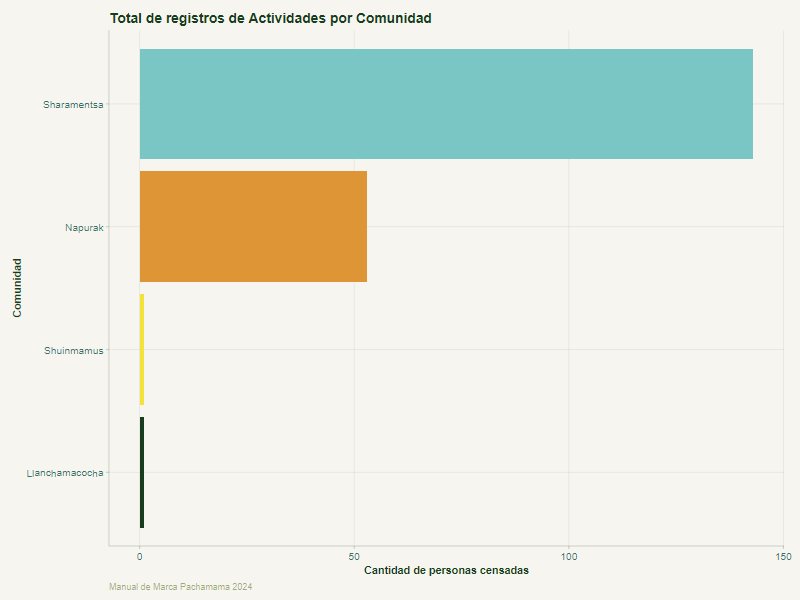

In [4]:
ggplot(conteo_actividades, aes(x = reorder(Comunidad, Total_registros), y = Total_registros, fill = Comunidad)) +
  geom_col(show.legend = FALSE) + # Las barras ya tienen el nombre abajo, no hace falta leyenda
  coord_flip() +                 # Giramos la gráfica para que los nombres de comunidades se lean bien
  scale_fill_pacha() +           # Colores oficiales de la Fundación
  labs(
    title = "Total de registros de Actividades por Comunidad",
    x = "Comunidad",
    y = "Cantidad de personas censadas",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +            # Tu tema personalizado
  theme(text = element_text(family = "sans")) # Evita errores si no tienes instalada la fuente Raleway

Cuando se hace una actividad y toma tiempo, el registro se hace cuando llega y se empieza la obra y se termina. Un solo registro, un solo informe del depsoito de como llegop la plata, que se hizo y que se obtuvo. Debe existir unb hash para cuando sale la plata y cuando se avaba la obra. Trazabilidad solicitud comunidad transferencia termino de actividad. 

Warning message:
Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`). 


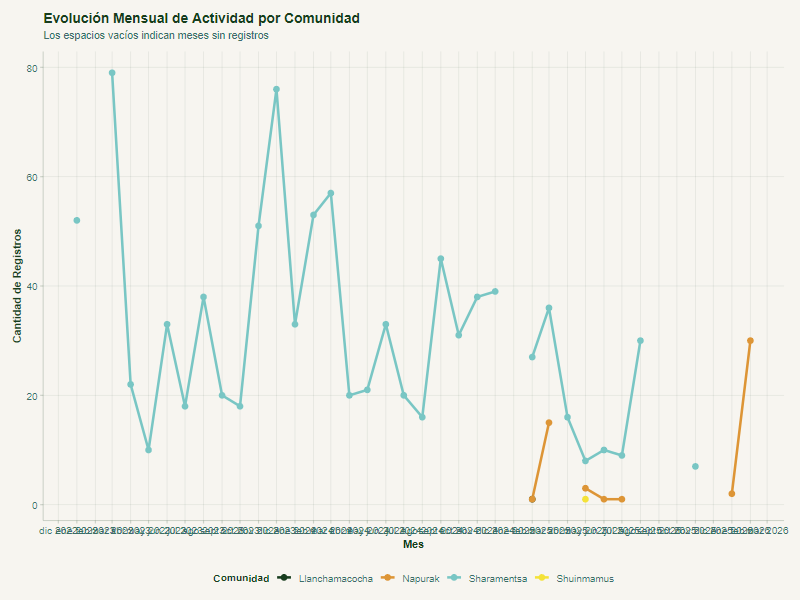

In [5]:

# 2. Procesar datos
serie_mensual <- planesv_df_0 %>%
  mutate(Mes = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes, Comunidad) %>%
  summarise(Total_registros = n(), .groups = "drop") %>%
  
  # Paso clave: Completar los meses faltantes por cada Comunidad
  group_by(Comunidad) %>%
  complete(Mes = seq(min(Mes), max(Mes), by = "month")) %>%
  
  # Paso clave 2: No convertir a 0, dejar como NA para que la línea se corte
  # Si quieres que el punto desaparezca también, déjalo como NA.
  mutate(Total_registros = ifelse(Total_registros == 0, NA, Total_registros)) %>%
  ungroup()

# 3. Generar la gráfica
ggplot(serie_mensual, aes(x = Mes, y = Total_registros, color = Comunidad, group = Comunidad)) +
  # na.rm = FALSE es el default, esto causará el hueco en la línea
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  
  scale_color_pacha() + 
  
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Evolución Mensual de Actividad por Comunidad",
    subtitle = "Los espacios vacíos indican meses sin registros",
    x = "Mes",
    y = "Cantidad de Registros",
    color = "Comunidad"
  ) +
  
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

## 3.2. Trabajo monitores

In [6]:
conteo_monitor = planesv_df_0  %>%
  filter(Fecha >= as.Date("2025-12-01"))%>%
  group_by(Monitor)%>%
  summarise(Total_registros = n())%>%
  arrange(-Total_registros)

conteo_monitor

# A tibble: 5 × 2
  Monitor                         Total_registros
  <chr>                                     <int>
1 Yampik_Tserem_Mainia_Pascualina              15
2 Tserem_Naranjas_Shakaim_Claudio              13
3 Claudio Tserem                                2
4 Claudio Tserem.                               1
5 Mukucham Tiriats                              1

## 3.3. Actividades

In [7]:
conteo_actividades = planesv_df_0  %>%
  filter(Fecha >= as.Date("2022-12-01"))%>%
  group_by(Comunidad, Actividad_monitorear, Tipo_accion )%>%
  summarise(Total_registros = n())%>%
  arrange(Comunidad)

conteo_actividades

`summarise()` has grouped output by 'Comunidad', 'Actividad_monitorear'. You
can override using the `.groups` argument.


# A tibble: 19 × 4
# Groups:   Comunidad, Actividad_monitorear [10]
   Comunidad      Actividad_monitorear   Tipo_accion           Total_registros
   <chr>          <chr>                  <chr>                           <int>
 1 Llanchamacocha Actividades economicas Entrega_de_insumos                  1
 2 Napurak        Actividades economicas Construcción                        2
 3 Napurak        Actividades economicas Otro                                1
 4 Napurak        Educación              Capacitacion_talleres               2
 5 Napurak        Salud                  Entrega_de_insumos                  1
 6 Napurak        Seguridad alimentaria  Entrega_de_insumos                 47
 7 Sharamentsa    Educación              Construcción                        1
 8 Sharamentsa    Educación              Otro                                1
 9 Sharamentsa    Otro                   Capacitacion_talleres               1
10 Sharamentsa    Otro                   Inspección            

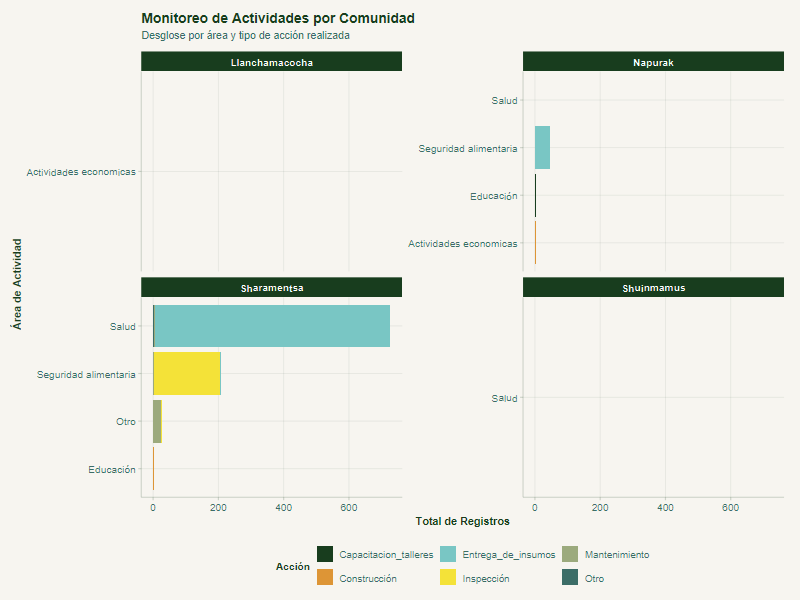

In [8]:
ggplot(conteo_actividades, aes(x = reorder(Actividad_monitorear, Total_registros), 
                               y = Total_registros, 
                               fill = Tipo_accion)) +
  geom_col() +
  coord_flip() +
  # Dividimos por Comunidad para que no se mezcle todo
  facet_wrap(~Comunidad, scales = "free_y") +
  scale_fill_manual(values = PAL_CUAL) +
  labs(
    title = "Monitoreo de Actividades por Comunidad",
    subtitle = "Desglose por área y tipo de acción realizada",
    x = "Área de Actividad",
    y = "Total de Registros",
    fill = "Acción"
  ) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

In [9]:
# 1. Transformar datos para Sankey (Flujo de 2 niveles)
flujo_1 <- conteo_actividades %>%
  group_by(Comunidad, Actividad_monitorear) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Comunidad, To = Actividad_monitorear)

flujo_2 <- conteo_actividades %>%
  group_by(Actividad_monitorear, Tipo_accion) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Actividad_monitorear, To = Tipo_accion)

# Unir los dos flujos
datos_sankey <- bind_rows(flujo_1, flujo_2)

# 2. Configurar colores de la Fundación para GoogleVis
# Usamos los códigos hexadecimales de tu paleta
colores_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts_sankey <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_js, ",
      label: { fontName: 'sans-serif', fontSize: 12, color: '", PAL$hoja, "' },
      interactivity: true
    },
    link: { 
      colorMode: 'gradient',
      colors: ", colores_js, "
    }
  }")
)

# 3. Generar el Plot de Sankey
sankey_pacha <- gvisSankey(datos_sankey, 
                           from = "De", 
                           to = "A", 
                           weight = "N. actividades",
                           options = opts_sankey)

# 4. Mostrar el gráfico (se abrirá en tu navegador)
plot(sankey_pacha)

## 3.4. Seguridad alimentaria

In [10]:
metadata_seguridad_alimentaria = planesv_df_0%>%filter(Actividad_monitorear == "Seguridad alimentaria")%>% # se puede activar o desactivar el filtro
  select(X_id,Comunidad, Fecha, Actividad_monitorear, Tipo_accion,  Quien_dirigido, Descripcion_accion, observaciones, n_ninos, n_ninas, n_hombres, n_mujeres, Total_mujeres, Total_hombres, Total_beneficiarios)

## Union con datos de seguridad alimentaria 

seguridad_alimentaria_all = metadata_seguridad_alimentaria%>%left_join(seguridad_alimentaria, by = c("X_id"))%>%
  left_join(entrega_insumos, by = c("X_id"))


### Flujo actividades

In [11]:
conteo_actividades_seguridad = seguridad_alimentaria_all%>%
  select(Comunidad,Tipo_accion,  seguridad_alimentaria)%>%
  group_by(Comunidad, Tipo_accion,  seguridad_alimentaria)%>%
  summarise(Total_registros = n())

conteo_actividades_seguridad

`summarise()` has grouped output by 'Comunidad', 'Tipo_accion'. You can
override using the `.groups` argument.


# A tibble: 10 × 4
# Groups:   Comunidad, Tipo_accion [5]
   Comunidad   Tipo_accion        seguridad_alimentaria Total_registros
   <chr>       <chr>              <chr>                           <int>
 1 Napurak     Entrega_de_insumos "Avicultura"                       31
 2 Napurak     Entrega_de_insumos "Pisicultura"                      16
 3 Sharamentsa Construcción       "Otro"                              1
 4 Sharamentsa Entrega_de_insumos "Avicultura"                        2
 5 Sharamentsa Entrega_de_insumos "Pisicultura"                       1
 6 Sharamentsa Inspección         ""                                  1
 7 Sharamentsa Inspección         "Avicultura"                      103
 8 Sharamentsa Inspección         "Otro"                              4
 9 Sharamentsa Inspección         "Pisicultura"                      95
10 Sharamentsa Mantenimiento      "Otro"                              2

In [12]:

# 0. Limpiar valores vacíos en todo el dataframe
conteo_limpio <- conteo_actividades_seguridad %>%
  mutate(across(where(is.character), ~ ifelse(.x == "" | is.na(.x), "No definido", .x)))

# 1. Flujo A: Tipo de Acción -> Seguridad Alimentaria
flujo_A <- conteo_limpio %>%
  group_by(Comunidad,Tipo_accion) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Comunidad, To = Tipo_accion)

# 2. Flujo B: Seguridad Alimentaria -> Quien dirigido
flujo_B <- conteo_limpio %>%
  group_by(Tipo_accion, seguridad_alimentaria) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Tipo_accion, To = seguridad_alimentaria)

# Unir flujos en la tabla maestra para el Sankey
datos_sankey_seg <- bind_rows(flujo_A, flujo_B)
datos_sankey_seg

# A tibble: 13 × 3
   From               To                 Weight
   <chr>              <chr>               <int>
 1 Napurak            Entrega_de_insumos     47
 2 Sharamentsa        Construcción            1
 3 Sharamentsa        Entrega_de_insumos      3
 4 Sharamentsa        Inspección            203
 5 Sharamentsa        Mantenimiento           2
 6 Construcción       Otro                    1
 7 Entrega_de_insumos Avicultura             33
 8 Entrega_de_insumos Pisicultura            17
 9 Inspección         Avicultura            103
10 Inspección         No definido             1
11 Inspección         Otro                    4
12 Inspección         Pisicultura            95
13 Mantenimiento      Otro                    2

In [13]:
# Colores oficiales para los nodos
colores_pacha_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts_sankey_seg <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_pacha_js, ",
      label: { fontName: 'Arial', fontSize: 13, color: '", PAL$hoja, "' },
      nodePadding: 30
    },
    link: { 
      colorMode: 'gradient',
      colors: ", colores_pacha_js, "
    }
  }")
)

# Crear el plot interactivo
sankey_seguridad <- gvisSankey(datos_sankey_seg, 
                               from = "From", 
                               to = "To", 
                               weight = "Weight",
                               options = opts_sankey_seg)

# Mostrar en el navegador
plot(sankey_seguridad)

### Actividades por año

In [14]:
serie_anual_alimentaria <- seguridad_alimentaria_all %>%
  mutate(Year = floor_date(as.Date(Fecha), "year")) %>%
  group_by(Year,Comunidad ) %>%
    summarise(Total_registros = n(), .groups = "drop") 
  serie_anual_alimentaria

# A tibble: 5 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2023-01-01 Sharamentsa             137
2 2024-01-01 Sharamentsa              14
3 2025-01-01 Napurak                  17
4 2025-01-01 Sharamentsa              58
5 2026-01-01 Napurak                  30

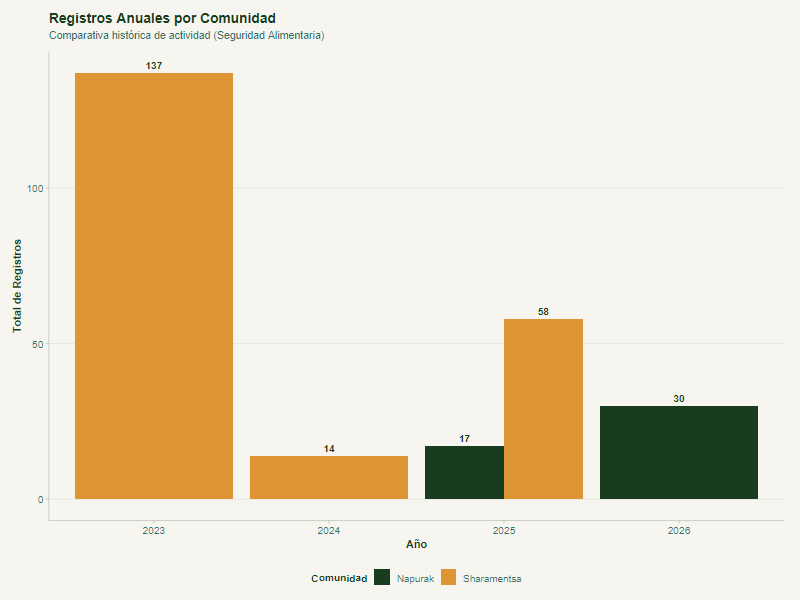

In [15]:

# Aseguramos que el año se trate como una categoría (factor) para que el eje X sea limpio
serie_anual_alimentaria <- serie_anual_alimentaria %>%
  mutate(Anio_Label = format(Year, "%Y"))

ggplot(serie_anual_alimentaria, aes(x = Anio_Label, y = Total_registros, fill = Comunidad)) +
  # position = "dodge" crea las barras una al lado de la otra
  geom_col(position = position_dodge(width = 0.9)) +
  
  # Añadir el total sobre cada barra
  geom_text(aes(label = Total_registros), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5,      # Ajuste vertical para que esté arriba de la barra
            size = 3.5, 
            fontface = "bold",
            color = PAL$hoja) +
  
  # Colores institucionales
  scale_fill_manual(values = PAL_CUAL) +
  
  labs(
    title = "Registros Anuales por Comunidad",
    subtitle = "Comparativa histórica de actividad (Seguridad Alimentaria)",
    x = "Año",
    y = "Total de Registros",
    fill = "Comunidad"
  ) +
  
  # Tu tema de la Fundación
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(), # Limpiamos el eje X para que se vea más moderno
    text = element_text(family = "sans")
  )

### Tasa de cambio anual

In [16]:

tasa_cambio_df <- serie_anual_alimentaria %>%
  # Aseguramos el orden cronológico por comunidad
  arrange(Comunidad, Year) %>%
  group_by(Comunidad) %>%
  # Calculamos el total del año anterior
  mutate(Total_anterior = lag(Total_registros)) %>%
  # Calculamos la tasa (solo donde hay un año previo)
  mutate(Tasa_Cambio = ((Total_registros - Total_anterior) / Total_anterior) * 100) %>%
  # Filtramos para quedarnos solo con los registros que tienen cálculo
  filter(!is.na(Tasa_Cambio)) %>%
  mutate(Anio_Label = format(Year, "%Y"))

tasa_cambio_df

# A tibble: 3 × 6
# Groups:   Comunidad [2]
  Year       Comunidad   Total_registros Anio_Label Total_anterior Tasa_Cambio
  <date>     <chr>                 <int> <chr>               <int>       <dbl>
1 2026-01-01 Napurak                  30 2026                   17        76.5
2 2024-01-01 Sharamentsa              14 2024                  137       -89.8
3 2025-01-01 Sharamentsa              58 2025                   14       314. 

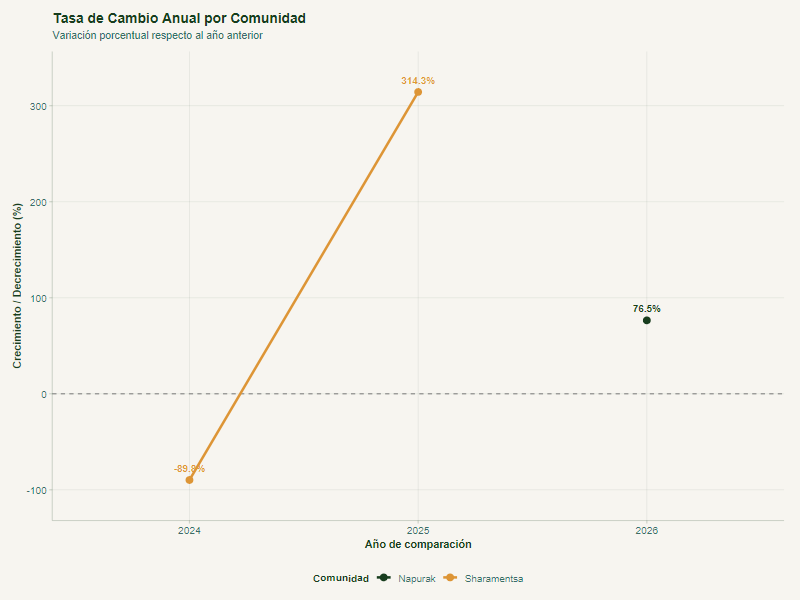

In [17]:
ggplot(tasa_cambio_df, aes(x = Anio_Label, y = Tasa_Cambio, color = Comunidad, group = Comunidad)) +
  # Línea de referencia en 0%
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  
  # Etiquetas de porcentaje sobre los puntos
  geom_text(aes(label = paste0(round(Tasa_Cambio, 1), "%")), 
            vjust = -1, size = 3.5, fontface = "bold", show.legend = FALSE) +
  
  scale_color_manual(values = PAL_CUAL) +
  
  labs(
    title = "Tasa de Cambio Anual por Comunidad",
    subtitle = "Variación porcentual respecto al año anterior",
    x = "Año de comparación",
    y = "Crecimiento / Decrecimiento (%)",
    color = "Comunidad"
  ) +
  
  # Ajuste de escala Y para dar espacio a las etiquetas
  expand_limits(y = c(min(tasa_cambio_df$Tasa_Cambio) - 20, max(tasa_cambio_df$Tasa_Cambio) + 20)) +
  
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

### Descripción y obs actividades

In [18]:
actividad_filtrada = seguridad_alimentaria_all%>%
  #filter(Actividad_monitorear == "Salud")%>% # se puede activar o desactivar el filtro
 # filter(Tipo_accion == "Entrega_de_insumos")%>%# se puede activar o desactivar el filtro
  select(Actividad_monitorear, Fecha, Tipo_accion, Descripcion_accion, observaciones,  Quien_dirigido, n_ninos, n_ninas, n_hombres, n_mujeres, Total_mujeres, Total_hombres, Total_beneficiarios)


In [19]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- actividad_filtrada %>%
  filter(!is.na(observaciones)) %>%
  filter(observaciones != "")%>%
  mutate(texto = str_to_lower(observaciones) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")

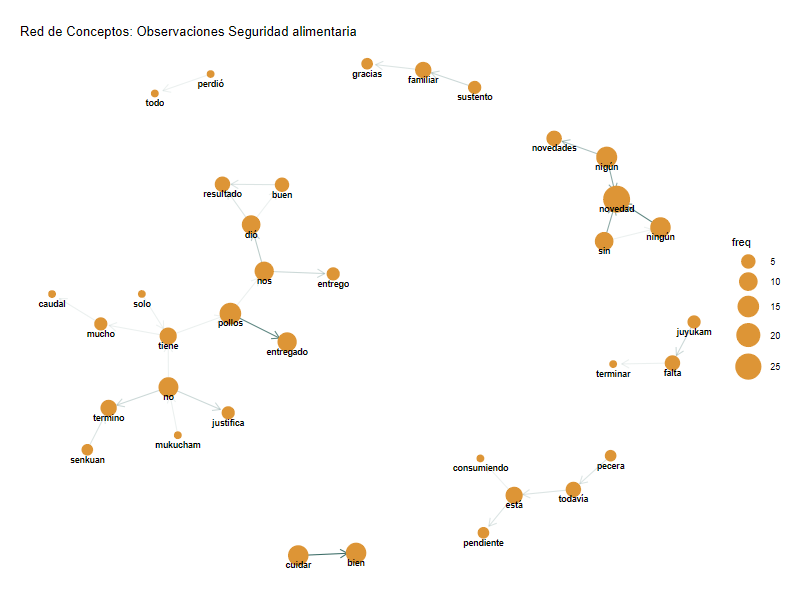

In [20]:
# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Observaciones Seguridad alimentaria",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

### Intensidad acciones de seguridad alimentaria

In [21]:
seguridad_alimentaria_all = seguridad_alimentaria_all %>%
  mutate(
    Fecha = as.Date(Fecha),
    Anio  = lubridate::year(Fecha)
  )
# ------------------------------------------------------------
# 2. LIMPIEZA Y VARIABLES DERIVADAS
# ------------------------------------------------------------
df_ind <- seguridad_alimentaria_all %>%
  mutate(
    # estandarizar nombres de estrategia
    seguridad_alimentaria = case_when(
      str_to_lower(seguridad_alimentaria) %in% c("pisicultura", "piscicultura") ~ "Piscicultura",
      str_to_lower(seguridad_alimentaria) %in% c("avicultura") ~ "Avicultura",
      TRUE ~ seguridad_alimentaria
    ),
    
    # unir texto libre en una sola variable para clasificar
    texto_resultado = str_to_lower(
      paste(
        coalesce(Descripcion_accion, ""),
        coalesce(observaciones, ""),
        sep = " | "
      )
    ),
    
    # clasificar resultado alimentario favorable reportado
    resultado_favorable = case_when(
      str_detect(texto_resultado, "sustento familiar|sustent[oó] familiar|consumo familiar|consumir con la familia|nos ayud[oó] en la familia|nos sirvi[oó]|buen resultado|apoy[oó] a vender|vender si hay necesidad") ~ 1,
      TRUE ~ 0
    ),
    
    # participación social: completar NAs con 0
    Total_mujeres = replace_na(Total_mujeres, 0),
    Total_hombres = replace_na(Total_hombres, 0),
    n_ninos = replace_na(n_ninos, 0),
    n_ninas = replace_na(n_ninas, 0),
    Total_beneficiarios = replace_na(Total_beneficiarios, 0),
    
    Total_ninez = n_ninos + n_ninas
  )


In [22]:

indicador_intensidad_anual <- df_ind %>%
  group_by(Comunidad, Anio) %>%
  summarise(
    n_acciones = n(),
    .groups = "drop"
  ) %>%
  arrange(Comunidad, Anio)

indicador_intensidad_anual

# A tibble: 5 × 3
  Comunidad    Anio n_acciones
  <chr>       <dbl>      <int>
1 Napurak      2025         17
2 Napurak      2026         30
3 Sharamentsa  2023        137
4 Sharamentsa  2024         14
5 Sharamentsa  2025         58

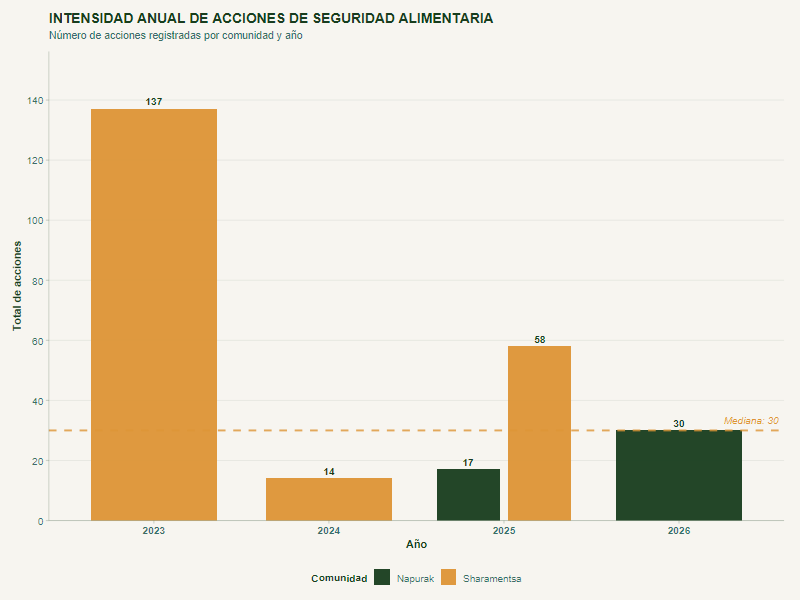

In [23]:
# ------------------------------------------------------------
# Gráfica: intensidad anual
# ------------------------------------------------------------

serie_anual_alimentaria <- indicador_intensidad_anual %>%
  mutate(
    Anio_Label = as.character(Anio)
  )

mediana_intensidad <- median(serie_anual_alimentaria$n_acciones, na.rm = TRUE)

ggplot(serie_anual_alimentaria,
       aes(x = Anio_Label, y = n_acciones, fill = Comunidad)) +
  
  geom_col(
    position = position_dodge(width = 0.82),
    width = 0.72,
    alpha = 0.95
  ) +
  
  geom_hline(
    yintercept = mediana_intensidad,
    linetype = "dashed",
    color = PAL$ave,
    linewidth = 0.9,
    alpha = 0.8
  ) +
  
  annotate(
    "text",
    x = Inf,
    y = mediana_intensidad,
    label = paste0("Mediana: ", round(mediana_intensidad, 1)),
    hjust = 1.1,
    vjust = -0.8,
    color = PAL$ave,
    fontface = "italic",
    size = 3.5,
    family = "Raleway"
  ) +
  
  geom_text(
    aes(label = n_acciones),
    position = position_dodge(width = 0.82),
    vjust = -0.45,
    size = 3.6,
    fontface = "bold",
    color = PAL$hoja,
    family = "Raleway"
  ) +
  
  scale_fill_manual(values = PAL_CUAL) +
  
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.14)),
    breaks = pretty_breaks(n = 6)
  ) +
  
  labs(
    title = "INTENSIDAD ANUAL DE ACCIONES DE SEGURIDAD ALIMENTARIA",
    subtitle = "Número de acciones registradas por comunidad y año",
    x = "Año",
    y = "Total de acciones",
    fill = "Comunidad"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom"
  )

### Diversidad de estrategias alimentarias

In [24]:
indicador_diversificacion_anual <- df_ind %>%
  group_by(Comunidad, Anio) %>%
  summarise(
    n_estrategias = n_distinct(seguridad_alimentaria[!is.na(seguridad_alimentaria)]),
    estrategias = paste(sort(unique(seguridad_alimentaria[!is.na(seguridad_alimentaria)])),
                        collapse = ", "),
    .groups = "drop"
  ) %>%
  arrange(Comunidad, Anio)

indicador_diversificacion_anual

# A tibble: 5 × 4
  Comunidad    Anio n_estrategias estrategias                   
  <chr>       <dbl>         <int> <chr>                         
1 Napurak      2025             2 Avicultura, Piscicultura      
2 Napurak      2026             2 Avicultura, Piscicultura      
3 Sharamentsa  2023             3 Avicultura, Otro, Piscicultura
4 Sharamentsa  2024             3 Avicultura, Otro, Piscicultura
5 Sharamentsa  2025             3 , Avicultura, Piscicultura    

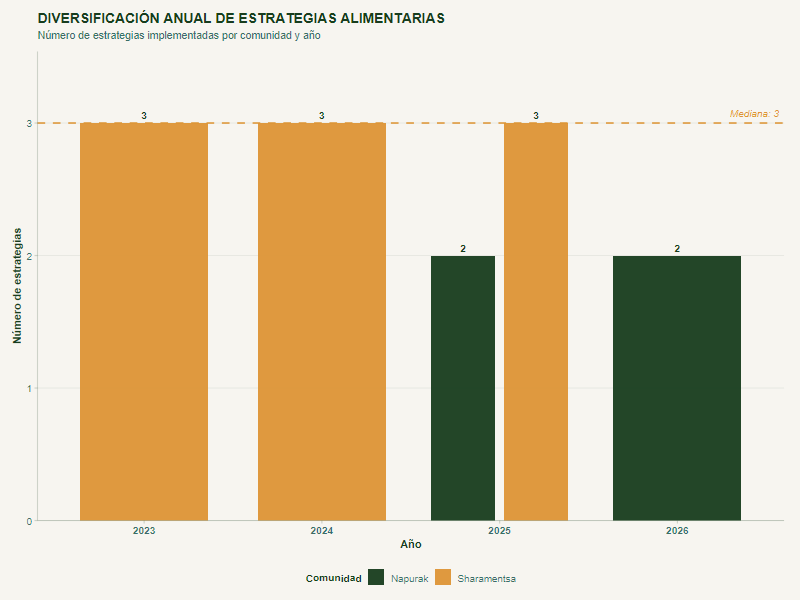

In [25]:
# ------------------------------------------------------------
# Gráfica: diversificación anual
# ------------------------------------------------------------

serie_diversificacion <- indicador_diversificacion_anual %>%
  mutate(
    Anio_Label = as.character(Anio)
  )

mediana_diversificacion <- median(serie_diversificacion$n_estrategias, na.rm = TRUE)

ggplot(serie_diversificacion,
       aes(x = Anio_Label, y = n_estrategias, fill = Comunidad)) +
  
  geom_col(
    position = position_dodge(width = 0.82),
    width = 0.72,
    alpha = 0.95
  ) +
  
  geom_hline(
    yintercept = mediana_diversificacion,
    linetype = "dashed",
    color = PAL$ave,
    linewidth = 0.9,
    alpha = 0.8
  ) +
  
  annotate(
    "text",
    x = Inf,
    y = mediana_diversificacion,
    label = paste0("Mediana: ", round(mediana_diversificacion, 1)),
    hjust = 1.1,
    vjust = -0.8,
    color = PAL$ave,
    fontface = "italic",
    size = 3.5,
    family = "Raleway"
  ) +
  
  geom_text(
    aes(label = n_estrategias),
    position = position_dodge(width = 0.82),
    vjust = -0.45,
    size = 3.6,
    fontface = "bold",
    color = PAL$hoja,
    family = "Raleway"
  ) +
  
  scale_fill_manual(values = PAL_CUAL) +
  
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.18)),
    breaks = pretty_breaks(n = 5)
  ) +
  
  labs(
    title = "DIVERSIFICACIÓN ANUAL DE ESTRATEGIAS ALIMENTARIAS",
    subtitle = "Número de estrategias implementadas por comunidad y año",
    x = "Año",
    y = "Número de estrategias",
    fill = "Comunidad"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom"
  )

### Proporción de iniciativas con resultado alimentario favorable reportado

In [26]:
indicador_resultado_favorable_anual <- df_ind %>%
  group_by(Comunidad, Anio) %>%
  summarise(
    n_registros = n(),
    n_favorables = sum(resultado_favorable, na.rm = TRUE),
    prop_favorables = (n_favorables / n_registros) * 100,
    .groups = "drop"
  ) %>%
  arrange(Comunidad, Anio)

indicador_resultado_favorable_anual

# A tibble: 5 × 5
  Comunidad    Anio n_registros n_favorables prop_favorables
  <chr>       <dbl>       <int>        <dbl>           <dbl>
1 Napurak      2025          17            0             0  
2 Napurak      2026          30            8            26.7
3 Sharamentsa  2023         137            0             0  
4 Sharamentsa  2024          14            0             0  
5 Sharamentsa  2025          58            0             0  

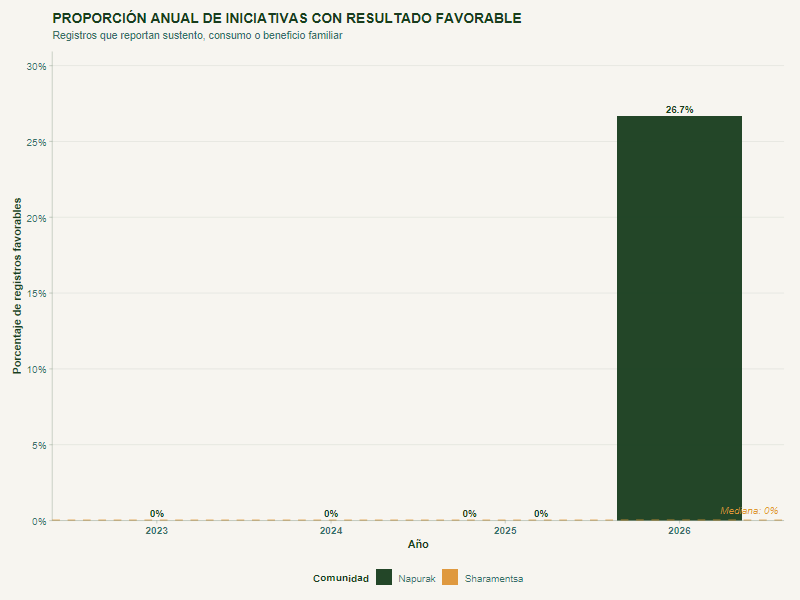

In [27]:
# ------------------------------------------------------------
# Gráfica: proporción anual de resultados favorables
# ------------------------------------------------------------

serie_resultado_favorable <- indicador_resultado_favorable_anual %>%
  mutate(
    Anio_Label = as.character(Anio)
  )

mediana_favorable <- median(serie_resultado_favorable$prop_favorables, na.rm = TRUE)

ggplot(serie_resultado_favorable,
       aes(x = Anio_Label, y = prop_favorables, fill = Comunidad)) +
  
  geom_col(
    position = position_dodge(width = 0.82),
    width = 0.72,
    alpha = 0.95
  ) +
  
  geom_hline(
    yintercept = mediana_favorable,
    linetype = "dashed",
    color = PAL$ave,
    linewidth = 0.9,
    alpha = 0.8
  ) +
  
  annotate(
    "text",
    x = Inf,
    y = mediana_favorable,
    label = paste0("Mediana: ", round(mediana_favorable, 1), "%"),
    hjust = 1.1,
    vjust = -0.8,
    color = PAL$ave,
    fontface = "italic",
    size = 3.5,
    family = "Raleway"
  ) +
  
  geom_text(
    aes(label = paste0(round(prop_favorables, 1), "%")),
    position = position_dodge(width = 0.82),
    vjust = -0.45,
    size = 3.4,
    fontface = "bold",
    color = PAL$hoja,
    family = "Raleway"
  ) +
  
  scale_fill_manual(values = PAL_CUAL) +
  
  scale_y_continuous(
    labels = percent_format(scale = 1),
    expand = expansion(mult = c(0, 0.16)),
    breaks = pretty_breaks(n = 6)
  ) +
  
  labs(
    title = "PROPORCIÓN ANUAL DE INICIATIVAS CON RESULTADO FAVORABLE",
    subtitle = "Registros que reportan sustento, consumo o beneficio familiar",
    x = "Año",
    y = "Porcentaje de registros favorables",
    fill = "Comunidad"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom"
  )

### Participación social diferenciada

In [28]:
# ============================================================
# 1. INDICADOR ANUAL DE PARTICIPACIÓN
# Separado por sexo y por grupo etario
# ============================================================

indicador_participacion_anual <- df_ind %>%
  mutate(
    n_hombres   = tidyr::replace_na(n_hombres, 0),
    n_mujeres   = tidyr::replace_na(n_mujeres, 0),
    n_ninos     = tidyr::replace_na(n_ninos, 0),
    n_ninas     = tidyr::replace_na(n_ninas, 0),
    Total_hombres = tidyr::replace_na(Total_hombres, 0),
    Total_mujeres = tidyr::replace_na(Total_mujeres, 0),
    Total_beneficiarios = tidyr::replace_na(Total_beneficiarios, 0)
  ) %>%
  group_by(Comunidad, Anio) %>%
  summarise(
    # Sexo
    total_hombres = sum(Total_hombres, na.rm = TRUE),   # hombres adultos + niños
    total_mujeres = sum(Total_mujeres, na.rm = TRUE),   # mujeres adultas + niñas
    
    # Grupo etario
    total_adultos = sum(n_hombres + n_mujeres, na.rm = TRUE),
    total_ninez   = sum(n_ninos + n_ninas, na.rm = TRUE),
    
    # Total general
    total_benef   = sum(Total_beneficiarios, na.rm = TRUE),
    
    # Porcentajes por sexo
    pct_mujeres = if_else(total_benef > 0, total_mujeres / total_benef * 100, NA_real_),
    pct_hombres = if_else(total_benef > 0, total_hombres / total_benef * 100, NA_real_),
    
    # Porcentajes por edad
    pct_adultos = if_else(total_benef > 0, total_adultos / total_benef * 100, NA_real_),
    pct_ninez   = if_else(total_benef > 0, total_ninez   / total_benef * 100, NA_real_),
    
    .groups = "drop"
  ) %>%
  arrange(Comunidad, Anio)
indicador_sexo_long <- indicador_participacion_anual %>%
  select(Comunidad, Anio, pct_mujeres, pct_hombres) %>%
  pivot_longer(
    cols = c(pct_mujeres, pct_hombres),
    names_to = "grupo",
    values_to = "porcentaje"
  ) %>%
  mutate(
    grupo = recode(
      grupo,
      pct_mujeres = "Mujeres",
      pct_hombres = "Hombres"
    ),
    grupo = factor(grupo, levels = c("Mujeres", "Hombres")),
    Anio_Label = as.character(Anio)
  )

  indicador_edad_long <- indicador_participacion_anual %>%
    select(Comunidad, Anio, pct_adultos, pct_ninez) %>%
    pivot_longer(
      cols = c(pct_adultos, pct_ninez),
      names_to = "grupo_etario",
      values_to = "porcentaje"
    ) %>%
    mutate(
      grupo_etario = recode(
        grupo_etario,
        pct_adultos = "Adultos",
        pct_ninez   = "Niñez"
      ),
      grupo_etario = factor(grupo_etario, levels = c("Adultos", "Niñez")),
      Anio_Label = as.character(Anio)
    )


Warning messages:
1: Removed 4 rows containing missing values or values outside the scale range
(`geom_col()`). 
2: Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`). 


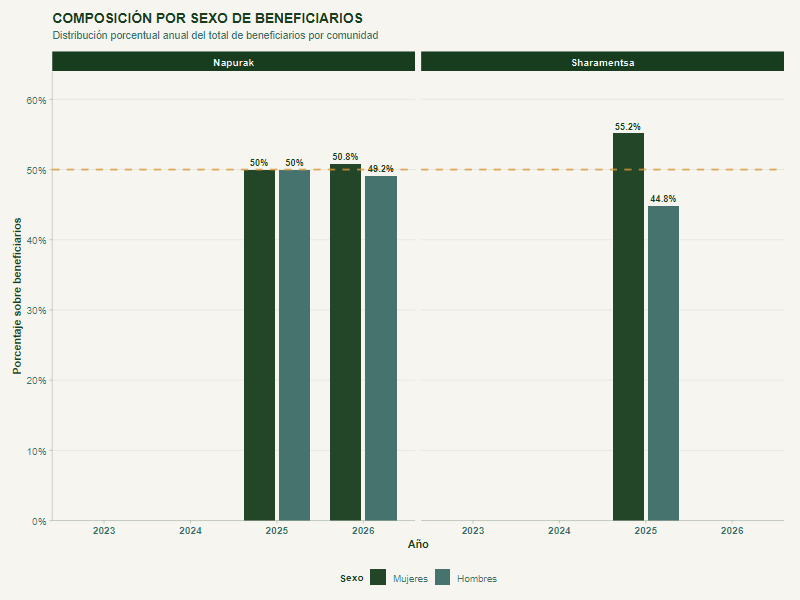

In [29]:
mediana_sexo <- median(indicador_sexo_long$porcentaje, na.rm = TRUE)

ggplot(indicador_sexo_long,
       aes(x = Anio_Label, y = porcentaje, fill = grupo)) +
  
  geom_col(
    position = position_dodge(width = 0.82),
    width = 0.72,
    alpha = 0.95
  ) +
  
  geom_hline(
    yintercept = mediana_sexo,
    linetype = "dashed",
    color = PAL$ave,
    linewidth = 0.85,
    alpha = 0.8
  ) +
  
  geom_text(
    aes(label = paste0(round(porcentaje, 1), "%")),
    position = position_dodge(width = 0.82),
    vjust = -0.45,
    size = 3.3,
    fontface = "bold",
    color = PAL$hoja,
    family = "Raleway"
  ) +
  
  facet_wrap(~ Comunidad) +
  
  scale_fill_manual(
    values = c(
      "Mujeres" = PAL$hoja,
      "Hombres" = PAL$rio
    )
  ) +
  
  scale_y_continuous(
    labels = percent_format(scale = 1),
    expand = expansion(mult = c(0, 0.16)),
    breaks = pretty_breaks(n = 5)
  ) +
  
  labs(
    title = "COMPOSICIÓN POR SEXO DE BENEFICIARIOS",
    subtitle = "Distribución porcentual anual del total de beneficiarios por comunidad",
    x = "Año",
    y = "Porcentaje sobre beneficiarios",
    fill = "Sexo"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom"
  )

Warning messages:
1: Removed 4 rows containing missing values or values outside the scale range
(`geom_col()`). 
2: Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`). 


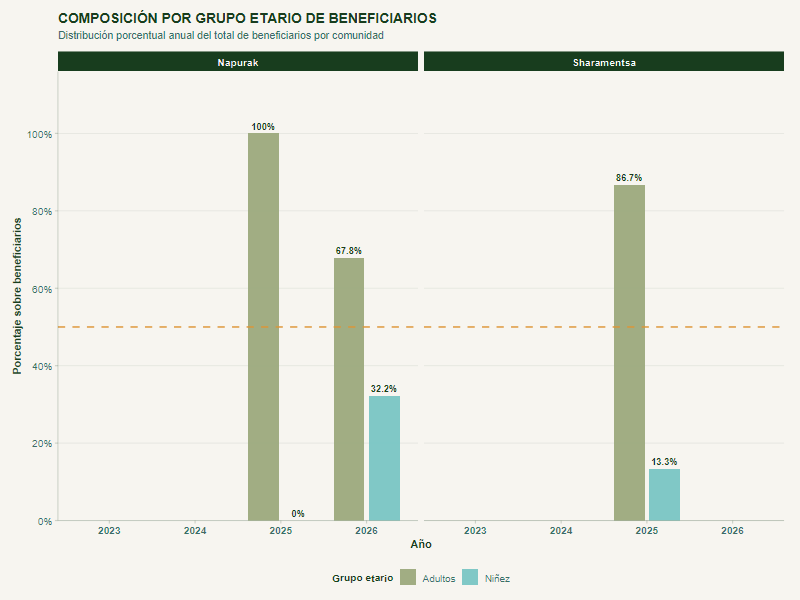

In [30]:
mediana_edad <- median(indicador_edad_long$porcentaje, na.rm = TRUE)

ggplot(indicador_edad_long,
       aes(x = Anio_Label, y = porcentaje, fill = grupo_etario)) +
  
  geom_col(
    position = position_dodge(width = 0.82),
    width = 0.72,
    alpha = 0.95
  ) +
  
  geom_hline(
    yintercept = mediana_edad,
    linetype = "dashed",
    color = PAL$ave,
    linewidth = 0.85,
    alpha = 0.8
  ) +
  
  geom_text(
    aes(label = paste0(round(porcentaje, 1), "%")),
    position = position_dodge(width = 0.82),
    vjust = -0.45,
    size = 3.3,
    fontface = "bold",
    color = PAL$hoja,
    family = "Raleway"
  ) +
  
  facet_wrap(~ Comunidad) +
  
  scale_fill_manual(
    values = c(
      "Adultos" = PAL$arcilla,
      "Niñez"   = PAL$cielo
    )
  ) +
  
  scale_y_continuous(
    labels = percent_format(scale = 1),
    expand = expansion(mult = c(0, 0.16)),
    breaks = pretty_breaks(n = 5)
  ) +
  
  labs(
    title = "COMPOSICIÓN POR GRUPO ETARIO DE BENEFICIARIOS",
    subtitle = "Distribución porcentual anual del total de beneficiarios por comunidad",
    x = "Año",
    y = "Porcentaje sobre beneficiarios",
    fill = "Grupo etario"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(),
    axis.text.x = element_text(face = "bold"),
    legend.position = "bottom"
  )

### Destino del beneficio

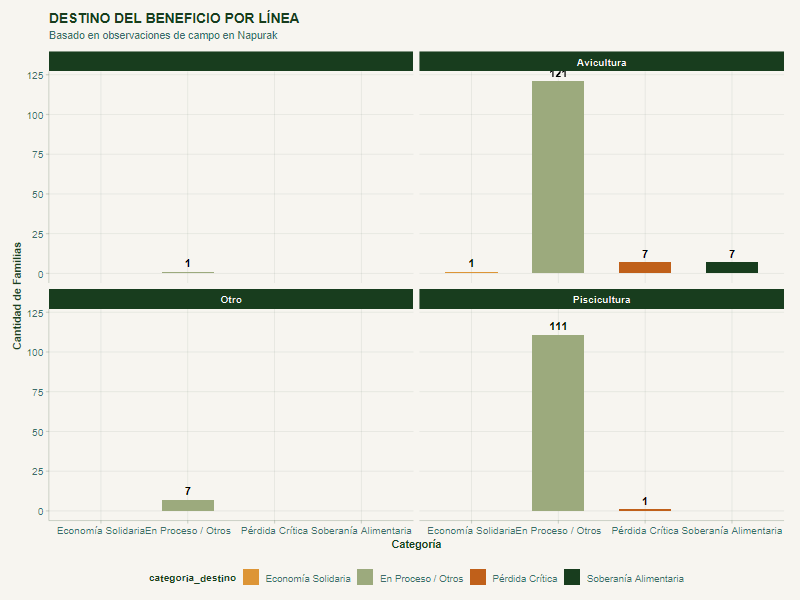

In [31]:
# Diccionarios de categorización
palabras_soberania <- "sustento|consumo|familia|alimentación"
palabras_economia  <- "vender|venta|mercado|comercial"
palabras_logro     <- "resultado|sirvió|ayudo|termino su pecera"
palabras_proceso   <- "falta|pendiente|no termino"
palabras_riesgo    <- "tigrillo|enfermedad|muriaron|no cumplió|terminó tigrillo"


calculo_destino <- df_ind %>%
  mutate(
    categoria_destino = case_when(
      str_detect(tolower(observaciones), "vender|venta") ~ "Economía Solidaria",
      str_detect(tolower(observaciones), "sustento|consumo|familia|ayudo|sirvió") ~ "Soberanía Alimentaria",
      str_detect(tolower(observaciones), "tigrillo|enfermedad|muriaron|terminó|termino") & 
        !str_detect(tolower(observaciones), "resultado|pecera") ~ "Pérdida Crítica",
      TRUE ~ "En Proceso / Otros"
    )
  ) %>%
  count(seguridad_alimentaria, categoria_destino) %>%
  group_by(seguridad_alimentaria) %>%
  mutate(pct = (n / sum(n)) * 100)

# Gráfico Destino (Estética Pachamama)
ggplot(calculo_destino, aes(x = categoria_destino, y = n, fill = categoria_destino)) +
  geom_col(width = 0.6) +
  facet_wrap(~seguridad_alimentaria) +
  geom_text(aes(label = n), vjust = -0.5, family = "Raleway", fontface = "bold") +
  scale_fill_manual(values = c(
    "Soberanía Alimentaria" = PAL$hoja,
    "Economía Solidaria"    = PAL$ave,
    "Pérdida Crítica"       = "#c0601a",
    "En Proceso / Otros"    = PAL$arcilla
  )) +
  labs(title = "DESTINO DEL BENEFICIO POR LÍNEA", 
       subtitle = "Basado en observaciones de campo en Napurak",
       x = "Categoría", y = "Cantidad de Familias") +
  theme_pachamama()

### Eficiencia de la Inversión Territorial (EIT)

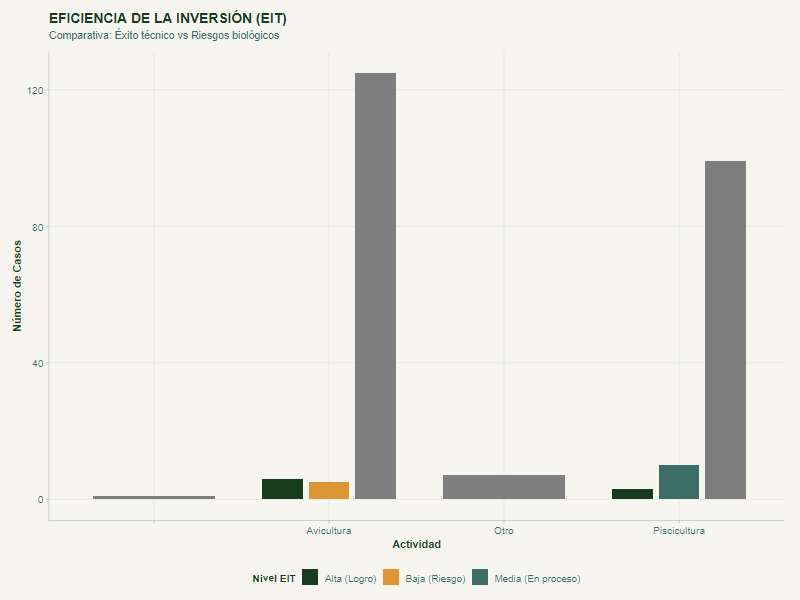

In [32]:
# Separamos el cálculo de EIT
calculo_eit <- df_ind %>%
  mutate(
    nivel_eit = case_when(
      # Éxito: Pecera terminada o reporte de "buen resultado"
      str_detect(tolower(observaciones), "termino su pecera|buen resultado|resultado") & 
        !str_detect(tolower(observaciones), "no termino|falta") ~ "Alta (Logro)",
      
      # Pendiente: Infraestructura no acabada
      str_detect(tolower(observaciones), "falta|pendiente|no termino") ~ "Media (En proceso)",
      
      # Falla: Muerte de animales o incumplimiento
      str_detect(tolower(observaciones), "tigrillo|enfermedad|muriaron|no cumplió") ~ "Baja (Riesgo)",
      
      TRUE ~ "No determinado"
    )
  ) %>%
  group_by(seguridad_alimentaria, nivel_eit) %>%
  summarise(total = n(), .groups = "drop")

# Gráfico EIT (Estética Pachamama)
ggplot(calculo_eit, aes(x = seguridad_alimentaria, y = total, fill = nivel_eit)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(values = c(
    "Alta (Logro)"   = PAL$hoja,
    "Media (En proceso)" = PAL$rio,
    "Baja (Riesgo)"      = PAL$ave
  )) +
  labs(title = "EFICIENCIA DE LA INVERSIÓN (EIT)",
       subtitle = "Comparativa: Éxito técnico vs Riesgos biológicos",
       x = "Actividad", y = "Número de Casos", fill = "Nivel EIT") +
  theme_pachamama()

### Problemática y aprendizajes

Se extrajo todas las observaciones y se analizó con GEMINI

In [33]:
actividad_filtrada %>%
  filter(!is.na(observaciones)) %>%
  mutate(texto = str_to_lower(observaciones) %>% str_replace_all("[^[:alpha:][:space:]]", ""))%>%
  filter(observaciones!= "")%>%
  pull(observaciones)

  [1] "No tiene mucho caudal de agua."                                                                 
  [2] "No tiene mucho caudal de agua"                                                                  
  [3] "No hay mucha  caudal de agua, están muy desnutrido."                                            
  [4] "Se está consumiendo muy pequeños."                                                              
  [5] "Ningún novedad"                                                                                 
  [6] "Ningún novedad"                                                                                 
  [7] "Sr. Sentsak está consumiendo mucho"                                                             
  [8] "Ningún novedad"                                                                                 
  [9] "Sin ningún novedad"                                                                             
 [10] "Ningún novedad"                                          

In [34]:


# Crear tabla
resultados <- tibble::tibble(
  Categoria = c(
    "Éxito y Sustento",
    "Estado de Avance",
    "Sanidad y Pérdidas",
    "Gestión de Recursos",
    "Cumplimiento y Cuidado"
  ),
  Hallazgos_Principales = c(
    "Muchos beneficiarios reportan que el proyecto sirvió para el sustento familiar y consumo propio.",
    "Hay un reporte detallado sobre la construcción de peceras; algunas terminadas y muchas pendientes.",
    "Se reportan muertes de animales por enfermedad y ataques de depredadores (tigrillo, leopardo, bao).",
    "Observaciones críticas sobre el bajo caudal de agua y la falta de materiales (tubos).",
    "Reportes de descuido por calamidad doméstica o viajes, y una constante instrucción de cuidar bien."
  )
)

# Imprimir en notebook
knitr::kable(resultados, caption = "Resumen de hallazgos")



Table: Resumen de hallazgos

|Categoria              |Hallazgos_Principales                                                                               |
|:----------------------|:---------------------------------------------------------------------------------------------------|
|Éxito y Sustento       |Muchos beneficiarios reportan que el proyecto sirvió para el sustento familiar y consumo propio.    |
|Estado de Avance       |Hay un reporte detallado sobre la construcción de peceras; algunas terminadas y muchas pendientes.  |
|Sanidad y Pérdidas     |Se reportan muertes de animales por enfermedad y ataques de depredadores (tigrillo, leopardo, bao). |
|Gestión de Recursos    |Observaciones críticas sobre el bajo caudal de agua y la falta de materiales (tubos).               |
|Cumplimiento y Cuidado |Reportes de descuido por calamidad doméstica o viajes, y una constante instrucción de cuidar bien.  |

**Análisis de Problemáticas Críticas**
A. El factor depredación y enfermedad
Es notable el uso del término "se terminó", que en este contexto parece indicar la pérdida total del lote de pollos.

Depredadores: Se mencionan específicamente el tigrillo, el leopardo y el bao. Esto indica que las infraestructuras de protección (galpones o mallas) podrían ser insuficientes para el entorno selvático/rural.

Sanidad: La "enfermedad" afectó a varios beneficiarios de manera fulminante.

B. Infraestructura Piscícola
Existe un cuello de botella en la construcción de peceras. Mientras que algunos terminaron (ej. Sr. Pantai, Sr. Cristóbal), un grupo significativo (Sres. Juyukam, Mukucham, Senkuan) las tiene "pendientes" o les "falta terminar". Esto sugiere falta de mano de obra, tiempo o materiales.

C. Recurso Hídrico
Las primeras observaciones alertan sobre el "poco caudal de agua". Esto es una bandera roja para los planes de vida que dependen de la piscicultura o riego, ya que sin agua suficiente, la producción es inviable a largo plazo.

**Principales Aprendizajes**
A partir de las observaciones, se pueden extraer las siguientes lecciones para el proyecto:

La vulnerabilidad ante el entorno natural es alta: No basta con entregar los pollos; el proyecto requiere mejorar los diseños de los refugios para evitar ataques de felinos y reptiles locales (tigrillos/bao).

Necesidad de asistencia técnica veterinaria: Las menciones a "enfermedades" que terminan con los pollos sugieren que no hubo un protocolo de vacunación o tratamiento oportuno, o que los beneficiarios no supieron identificar los síntomas a tiempo.

El éxito está ligado a la seguridad alimentaria: El aprendizaje más positivo es que, cuando el ciclo se completa, el impacto en la economía familiar es directo ("sustento familiar" y "apoyo a vender"). El proyecto es pertinente y valorado.

Seguimiento diferenciado en infraestructura: Hay una brecha entre la entrega de materiales (tubos) y la finalización de las peceras. El aprendizaje es que la entrega de insumos debe ir acompañada de un cronograma de trabajo físico supervisado.

Factores sociales externos: Las "calamidades" y viajes de los beneficiarios afectan la continuidad. El proyecto debe contemplar planes de contingencia (quién cuida los animales si el titular se ausenta) para evitar la pérdida total de la inversión.

### Posibles futuros indicadores

Indicador de Destino del Beneficio (Soberanía vs. Economía):  Clasifica si la producción se usa para el autoconsumo ("sustento familiar") o si genera excedentes para el intercambio/venta ("vender si hay necesidad"). Entender si el proyecto solo mitiga el hambre o si está fortaleciendo la economía solidaria Achuar. Clasificación cualitativa de las observaciones: (C = Consumo, V = Venta, P = Pérdida). 

Eficiencia de la "Inversión Territorial" (EIT): Relaciona el insumo entregado con la satisfacción o percepción de resultado positivo expresado por el socio. Medir la pertinencia del proyecto desde la voz del beneficiario (basado en frases como "nos dio buen resultado"). Análisis de sentimiento de la columna "observaciones". Conteo de menciones de "Gracias/Resultado positivo" vs "Se terminó/Falta".

## 3.5. Salud

In [35]:
salud_df = planesv_df_0%>%filter(Actividad_monitorear == "Salud")



### Estandarizar valores

In [36]:
# =============================================================================
# ESTANDARIZACIÓN DE Descripcion_accion
# Proyecto: Monitoreo de salud en comunidades indígenas amazónicas
# Lógica: normalizar → clasificar medicamentos → clasificar tipo de acción
# =============================================================================


# -----------------------------------------------------------------------------
# PASO 1: Función de normalización base
# Convierte a minúsculas, elimina tildes, espacios extra y caracteres extraños
# -----------------------------------------------------------------------------

normalizar_texto <- function(x) {
  x |>
    str_to_lower() |>
    str_replace_all("[áàä]", "a") |>
    str_replace_all("[éèë]", "e") |>
    str_replace_all("[íìï]", "i") |>
    str_replace_all("[óòö]", "o") |>
    str_replace_all("[úùü]", "u") |>
    str_replace_all("[ñ]", "n") |>
    str_squish() |>
    str_replace_all("\\.$", "")   # quitar punto final
}

# -----------------------------------------------------------------------------
# PASO 2: Diccionario de estandarización de medicamentos
# Clave: patrón regex (sobre texto normalizado) → Valor: nombre canónico
# Orden importa: los más específicos primero
# -----------------------------------------------------------------------------

dict_medicamentos <- c(
  # Antibióticos
  "amoxicilina|amoxicher|amxicilina|moxilan"  = "Amoxicilina",
  "ampicilina"                                 = "Ampicilina",
  "bactrim"                                    = "Bactrim (cotrimoxazol)",
  "dicloxacilina"                              = "Dicloxacilina",
  "binozyt"                                    = "Azitromicina (Binozyt)",

  # Antiparasitarios
  "albendazol|alvendazol"                      = "Albendazol",

  # Analgésicos / antiinflamatorios / antipiréticos
  "paracetamol|paracetanol|parcetamol"         = "Paracetamol",
  "paralgen"                                   = "Paracetamol (Paralgen)",   # Paralgen es marca de paracetamol
  "ibuprofeno"                                 = "Ibuprofeno",
  "aspirina"                                   = "Aspirina",
  "finalin"                                    = "Finalin (analgésico)",
  "diclofenaco|diclifenaco"                    = "Diclofenaco",
  "doloneurobion|doloneorobion|doloneurobiom|doloneurobion" = "Doloneurobion",
  "buscapina"                                  = "Buscapina",
  "umbral"                                     = "Umbral (analgésico)",
  "paragel"                                    = "Paragel (analgésico tópico)",

  # Vitaminas / suplementos
  "bedoyecta"                                  = "Complejo B (Bedoyecta)",
  "neurobion"                                  = "Complejo B (Neurobion)",
  "garden forte"                               = "Suplemento vitamínico (Garden Forte)",
  "olimpic"                                    = "Suplemento (Olimpic)",

  # Gastrointestinales / hidratación
  "diaren"                                     = "Diaren (antidiarreico)",
  "entero germina|enterogermina"               = "Enterogermina (probiótico)",
  "entero germina|enterogermina|bonagermin"    = "Probiótico intestinal",
  "metoclox"                                   = "Metoclopramida (Metoclox)",
  "fagol"                                      = "Fagol (antiparasitario GI)",
  "suero oral|solucion oral"                   = "Suero oral / rehidratación",

  # Respiratorio
  "nebulasma"                                  = "Nebulasma (broncodilatador)",
  "bisolvon"                                   = "Bisolvon (mucolítico)",
  "tussin"                                     = "Jarabe antitusivo",
  "jarabe"                                     = "Jarabe (sin especificar)",
  "lemonflu"                                   = "Lemonflu (antigripal)",

  # Oftalmológico / tópico
  "oftagen"                                    = "Colirio (Oftagen)",
  "lubriderm"                                  = "Crema hidratante (Lubriderm)",
  "mentol panalgesic|mentol panaldesic"        = "Mentol Panalgesic (tópico)",
  "mentol chino"                               = "Mentol chino (tópico)",

  # Otros / no clasificados por similitud
  "molarex|molalex"                            = "Molarex (sin clasificar)",
  "trigentax|trejentax"                        = "Trejentax (sin clasificar)",
  "acronistina"                                = "Acronistina (sin clasificar)",
  "tabletas"                                   = "Tabletas (sin especificar)",
  "loratadina"                                 = "Loratadina (antihistamínico)"
)

# -----------------------------------------------------------------------------
# PASO 3: Clasificación farmacológica (grupos para indicadores)
# -----------------------------------------------------------------------------

grupos_farmacologicos <- c(
  "Amoxicilina"                    = "Antibiótico",
  "Ampicilina"                     = "Antibiótico",
  "Bactrim (cotrimoxazol)"         = "Antibiótico",
  "Dicloxacilina"                  = "Antibiótico",
  "Azitromicina (Binozyt)"         = "Antibiótico",
  "Albendazol"                     = "Antiparasitario",
  "Fagol (antiparasitario GI)"     = "Antiparasitario",
  "Paracetamol"                    = "Analgésico/Antipirético",
  "Paracetamol (Paralgen)"         = "Analgésico/Antipirético",
  "Ibuprofeno"                     = "Analgésico/Antipirético",
  "Aspirina"                       = "Analgésico/Antipirético",
  "Finalin (analgésico)"           = "Analgésico/Antipirético",
  "Diclofenaco"                    = "Antiinflamatorio (AINE)",
  "Doloneurobion"                  = "Antiinflamatorio (AINE)",
  "Buscapina"                      = "Espasmolítico",
  "Umbral (analgésico)"            = "Analgésico/Antipirético",
  "Paragel (analgésico tópico)"    = "Tópico",
  "Complejo B (Bedoyecta)"         = "Vitaminas/Suplemento",
  "Complejo B (Neurobion)"         = "Vitaminas/Suplemento",
  "Suplemento vitamínico (Garden Forte)" = "Vitaminas/Suplemento",
  "Suplemento (Olimpic)"           = "Vitaminas/Suplemento",
  "Diaren (antidiarreico)"         = "Gastrointestinal",
  "Probiótico intestinal"          = "Gastrointestinal",
  "Enterogermina (probiótico)"     = "Gastrointestinal",
  "Metoclopramida (Metoclox)"      = "Gastrointestinal",
  "Suero oral / rehidratación"     = "Hidratación",
  "Nebulasma (broncodilatador)"    = "Respiratorio",
  "Bisolvon (mucolítico)"          = "Respiratorio",
  "Jarabe antitusivo"              = "Respiratorio",
  "Jarabe (sin especificar)"       = "Respiratorio",
  "Lemonflu (antigripal)"          = "Respiratorio",
  "Colirio (Oftagen)"              = "Oftalmológico",
  "Crema hidratante (Lubriderm)"   = "Tópico",
  "Mentol Panalgesic (tópico)"     = "Tópico",
  "Mentol chino (tópico)"          = "Tópico"
)

# -----------------------------------------------------------------------------
# PASO 4: Clasificación del TIPO DE ACCIÓN (para texto narrativo)
# Detecta si la descripción es un medicamento, una visita, u otra acción
# -----------------------------------------------------------------------------

clasificar_tipo_accion <- function(texto_norm) {
  case_when(
    # Visitas domiciliarias
    str_detect(texto_norm, "visita|visite|se visito") ~ "Visita domiciliaria",

    # Acompañamiento a servicios externos
    str_detect(texto_norm, "brigada|patronato|puesto de salud|acompan") ~ "Acompañamiento a servicio externo",

    # Pruebas / diagnóstico
    str_detect(texto_norm, "prueba|rabita|diagnostico") ~ "Diagnóstico / prueba",

    # Entrega genérica de medicamento (sin especificar cuál)
    str_detect(texto_norm, "entrega de medicamento|entregue medicamento|entregue medicina|entrega de medicina|entrego medicina") ~ "Entrega medicamento (sin especificar)",

    # Saneamiento
    str_detect(texto_norm, "hoyo sanitario|saneamiento") ~ "Saneamiento ambiental",

    # Actividades no relacionadas a salud directa
    str_detect(texto_norm, "utiles escolares|violin rojo|cecib") ~ "Actividad no relacionada a salud",

    # Valor vacío o solo espacios
    str_detect(texto_norm, "^\\s*$") | is.na(texto_norm) ~ "Sin descripción",

    TRUE ~ NA_character_
  )
}

# -----------------------------------------------------------------------------
# PASO 5: Función principal de estandarización
# Devuelve columnas nuevas sin modificar las originales
# -----------------------------------------------------------------------------

estandarizar_descripcion <- function(df, col = "Descripcion_accion") {

  df |>
    mutate(
      # 5a. Texto normalizado (solo para procesamiento interno)
      .desc_norm = normalizar_texto(.data[[col]]),

      # 5b. Intentar mapear a nombre canónico de medicamento
      medicamento_canonico = {
        med <- NA_character_
        for (patron in names(dict_medicamentos)) {
          med <- if_else(
            is.na(med) & str_detect(.desc_norm, patron),
            dict_medicamentos[[patron]],
            med
          )
        }
        med
      },

      # 5c. Tipo de acción para registros narrativos (no medicamentos)
      tipo_accion_narrativa = if_else(
        is.na(medicamento_canonico),
        clasificar_tipo_accion(.desc_norm),
        NA_character_
      ),

      # 5d. Etiqueta unificada para análisis:
      #     medicamento canónico si lo hubo, tipo de acción si no
      desc_estandarizada = coalesce(medicamento_canonico, tipo_accion_narrativa, "No clasificado"),

      # 5e. Grupo farmacológico (solo aplica a medicamentos)
      grupo_farmacologico = grupos_farmacologicos[medicamento_canonico],

      # 5f. Flag: ¿es medicamento o acción?
      es_medicamento = !is.na(medicamento_canonico),

      # Limpiar columna auxiliar
      .desc_norm = NULL
    )
}

# -----------------------------------------------------------------------------
# PASO 6: Aplicar sobre el dataframe (reemplaza 'datos' por tu objeto)
# -----------------------------------------------------------------------------

# datos <- estandarizar_descripcion(datos)

# Verificación rápida de cobertura:
verificar_cobertura <- function(df_estandarizado) {
  df_estandarizado |>
    count(desc_estandarizada, grupo_farmacologico, es_medicamento, sort = TRUE) |>
    mutate(
      pct = round(n / sum(n) * 100, 1)
    )
}

# Para ver registros no clasificados:
ver_no_clasificados <- function(df_estandarizado, col_original = "Descripcion_accion") {
  df_estandarizado |>
    filter(desc_estandarizada == "No clasificado") |>
    select(all_of(col_original), desc_estandarizada) |>
    distinct()
}

# -----------------------------------------------------------------------------
# PASO 7: Tabla resumen para indicadores de diversidad (Shannon H')
# -----------------------------------------------------------------------------

tabla_diversidad_insumos <- function(df_estandarizado) {
  df_estandarizado |>
    filter(es_medicamento) |>
    group_by(Comunidad, grupo_farmacologico) |>
    summarise(n = n(), .groups = "drop") |>
    group_by(Comunidad) |>
    mutate(
      p = n / sum(n),
      shannon_H = -sum(p * log(p)),
      total_entregas = sum(n)
    ) |>
    ungroup() |>
    distinct(Comunidad, shannon_H, total_entregas) |>
    arrange(desc(shannon_H))
}

# =============================================================================
# EJEMPLO DE USO COMPLETO:
#

salud_df <- estandarizar_descripcion(salud_df)
cobertura <- verificar_cobertura(salud_df)
no_clasif <- ver_no_clasificados(salud_df)
diversidad <- tabla_diversidad_insumos(salud_df)

### Flujo de actividades

In [37]:


# 1. Preparación y cálculo de beneficiarios
conteo_limpio <- salud_df %>%
  # Limpiar valores vacíos
  mutate(across(where(is.character), ~ ifelse(.x == "" | is.na(.x), "No definido", .x))) %>%
  # Asegurar que los conteos sean numéricos y tratar NAs como 0 para la suma
  mutate(across(c(n_ninos, n_ninas, n_hombres, n_mujeres), ~ replace_na(as.numeric(.x), 0))) %>%
  # Calcular el peso basado en beneficiarios
  mutate(Total_beneficiarios = n_ninos + n_ninas + n_hombres + n_mujeres)

# 2. Flujo A: Comunidad -> Tipo de Acción
flujo_A <- conteo_limpio %>%
  group_by(Comunidad, Tipo_accion) %>%
  summarise(Weight = sum(Total_beneficiarios, na.rm = TRUE), .groups = "drop") %>%
  rename(From = Comunidad, To = Tipo_accion)

# 3. Flujo B: Tipo de Acción -> A quién va dirigido
flujo_B <- conteo_limpio %>%
  group_by(Tipo_accion, Quien_dirigido) %>%
  summarise(Weight = sum(Total_beneficiarios, na.rm = TRUE), .groups = "drop") %>%
  rename(From = Tipo_accion, To = Quien_dirigido)

# 4. Unir flujos
datos_sankey_final <- bind_rows(flujo_A, flujo_B) %>%
  filter(Weight > 0) # Eliminar flujos de peso cero para evitar errores en el plot

# 5. Generar la visualización
colores_pacha_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_pacha_js, ",
      label: { fontName: 'Arial', fontSize: 12, color: '", PAL$hoja, "' }
    },
    link: { colorMode: 'gradient', colors: ", colores_pacha_js, " }
  }")
)

sankey_plot <- gvisSankey(datos_sankey_final, 
                          from = "From", 
                          to = "To", 
                          weight = "Weight", 
                          options = opts)

plot(sankey_plot)

### Nube de palabras

In [38]:

# 1. Definir Stop Words (palabras a excluir)
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", 
                                     "entrega", "insumos", "accion", "descripcion"))

# 2. Tokenizar y contar frecuencias
conteo_palabras <- data.frame(texto = salud_df$Descripcion_accion) %>%
  mutate(texto = str_to_lower(texto) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(word, texto) %>%
  filter(!word %in% stop_words_es$word) %>%
  count(word, sort = TRUE) %>%
  filter(nchar(word) > 2) # Evitar palabras de 1 o 2 letras

There were 14 warnings (use warnings() to see them)


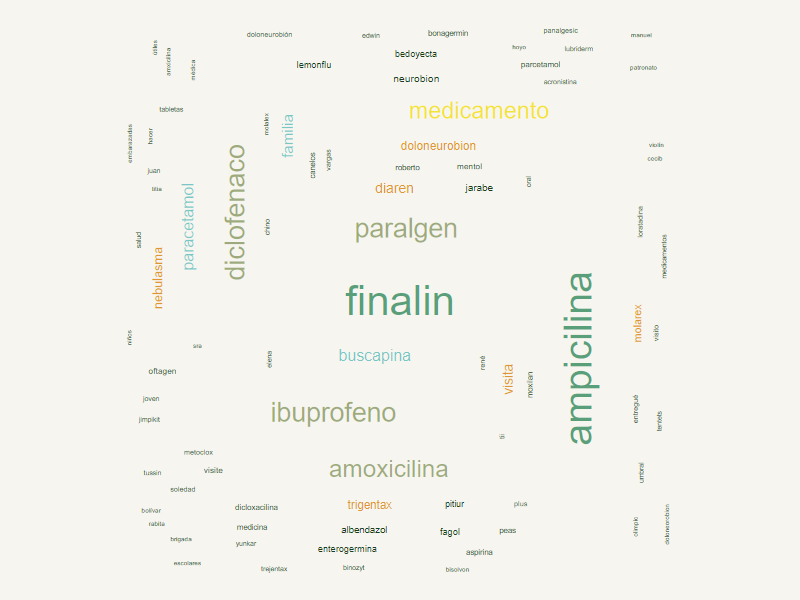

In [39]:
# Configurar el área de dibujo
par(bg = PAL$fondo) # Usar el color de fondo de tu marca

wordcloud(
  words = conteo_palabras$word, 
  freq = conteo_palabras$n, 
  min.freq = 1,           # Mostrar incluso las que aparecen una vez
  max.words = 100,        # Limitar a las 100 más frecuentes para que sea legible
  random.order = FALSE,   # Las más grandes al centro
  rot.per = 0.35,         # 35% de palabras en vertical
  colors = as.character(PAL_CUAL),
  scale = c(3.5, 0.5),    # Ajustar tamaño máximo y mínimo de letra
  family = "sans"
)

### Entrega de medicamentos en el tiempo

In [40]:


# 1. Preparación y Agrupación de Datos
df_mensual <- salud_df %>%
  # Asegurar que la fecha sea reconocida y crear una etiqueta mensual (Ej: 2024-05)
mutate(
  # Creamos una columna de fecha truncada al mes para agrupar correctamente
  Mes_Fecha = floor_date(as.Date(Fecha), "month")
)%>%
  filter(!is.na(grupo_farmacologico))%>%
  filter( es_medicamento == TRUE)%>%
  group_by(Mes_Fecha, grupo_farmacologico, Comunidad) %>%
  summarise(Total_beneficiarios = sum(Total_beneficiarios, na.rm = TRUE), .groups = 'drop')%>%
  as.data.frame()%>%
  ungroup()


total_medicamentos = df_mensual%>%
  group_by(  grupo_farmacologico)%>%
  summarise(Total = sum(Total_beneficiarios))%>%
  arrange(-Total)%>%
  filter(Total>= 34)

nombres_medicamentos_filtrados = total_medicamentos%>%pull(grupo_farmacologico)
df_mensual_filtrado  = df_mensual %>% filter(grupo_farmacologico %in%nombres_medicamentos_filtrados )


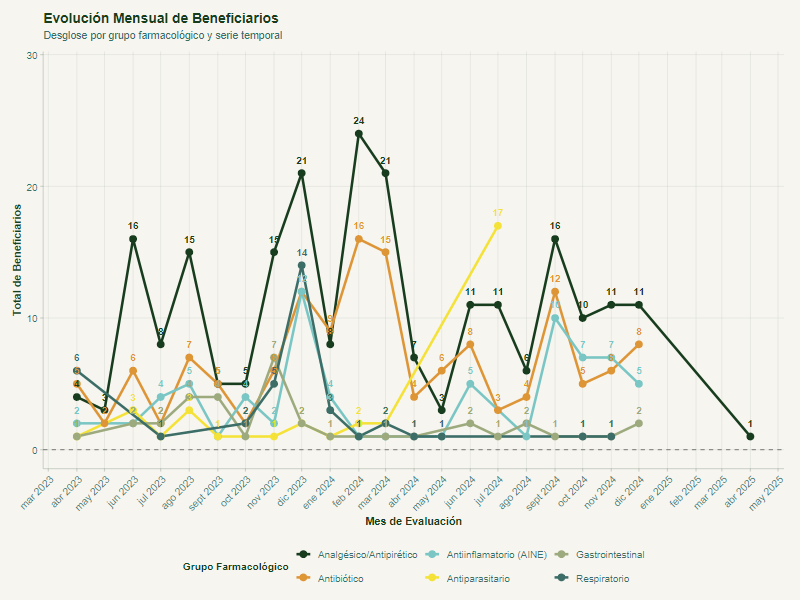

In [41]:
# 2. Creación de la gráfica de Serie de Tiempo
ggplot(df_mensual_filtrado, aes(x = Mes_Fecha, y = Total_beneficiarios, 
  color = grupo_farmacologico, group = grupo_farmacologico)) +

# Línea de referencia en 0 (siguiendo tu estilo base)
geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +

# Líneas y puntos con los grosores del manual
geom_line(linewidth = 1.2) +
geom_point(size = 3) +

# Etiquetas de valores sobre los puntos
geom_text(aes(label = Total_beneficiarios), 
vjust = -1.2, 
size = 3.5, 
fontface = "bold", 
show.legend = FALSE) +

# Aplicación de Escalas de Color de la Fundación Pachamama
scale_color_manual(values = PAL_CUAL) +

# Formateo del eje X para que muestre Mes-Año (Ene 2024)
scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +

# Etiquetas de texto
labs(
title = "Evolución Mensual de Beneficiarios",
subtitle = "Desglose por grupo farmacológico y serie temporal",
x = "Mes de Evaluación",
y = "Total de Beneficiarios",
color = "Grupo Farmacológico"
) +

# Damos espacio superior para que no se corten las etiquetas
expand_limits(y = max(df_mensual$Total_beneficiarios) * 1.2) +

# APLICACIÓN DEL TEMA OFICIAL PACHAMAMA
theme_pachamama() +
theme(
axis.text.x = element_text(angle = 45, hjust = 1) # Inclinación para legibilidad
)

### Tasa de uso de Antibioticos respecto al resto

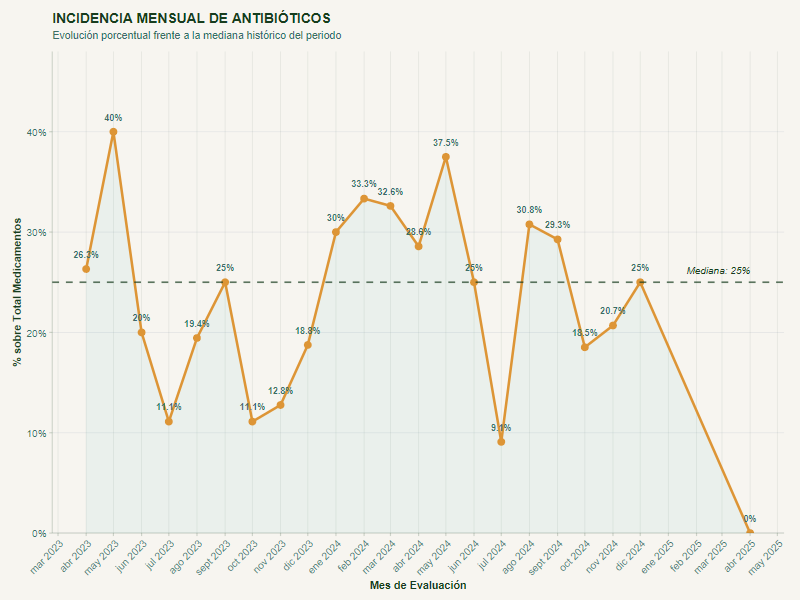

In [42]:
# 1. Procesamiento y cálculo de la media
df_antibioticos_tasa <- salud_df %>%
  mutate(Mes_Fecha = floor_date(as.Date(Fecha), "month")) %>%
  filter(!is.na(grupo_farmacologico), es_medicamento == TRUE) %>%
  group_by(Mes_Fecha) %>%
  summarise(
    Total_Mensual = sum(Total_beneficiarios, na.rm = TRUE),
    Total_Antibioticos = sum(Total_beneficiarios[grupo_farmacologico == "Antibiótico"], na.rm = TRUE),
    Tasa_Porcentaje = (Total_Antibioticos / Total_Mensual) * 100,
    .groups = 'drop'
  ) %>%
  mutate(Tasa_Porcentaje = if_else(is.nan(Tasa_Porcentaje), 0, Tasa_Porcentaje))

# Calcular el promedio global de la serie para la línea de referencia
mediana_global <- median(df_antibioticos_tasa$Tasa_Porcentaje, na.rm = TRUE)

# 2. Gráfica con línea de promedio
ggplot(df_antibioticos_tasa, aes(x = Mes_Fecha, y = Tasa_Porcentaje)) +
  
  # Área y líneas base
  geom_area(fill = PAL$cielo, alpha = 0.1) +
  geom_line(color = PAL$ave, linewidth = 1.2) +
  geom_point(color = PAL$ave, size = 3) +
  
  # LÍNEA DE PROMEDIO (Regla solicitada)
  geom_hline(yintercept = mediana_global, 
             linetype = "dashed", 
             color = PAL$hoja, 
             linewidth = 0.8, 
             alpha = 0.7) +
  
  # Etiqueta para la línea de promedio
  annotate("text", 
           x = max(df_antibioticos_tasa$Mes_Fecha), 
           y = mediana_global, 
           label = paste0("Mediana: ", round(mediana_global, 1), "%"), 
           vjust = -1, 
           hjust = 1, 
           color = PAL$hoja, 
           fontface = "italic", 
           size = 3.5) +

  # Etiquetas de porcentaje sobre los puntos
  geom_text(aes(label = paste0(round(Tasa_Porcentaje, 1), "%")), 
            vjust = -1.5, 
            size = 3.2, 
            fontface = "bold",
            color = PAL$rio) +
  
  # Escalas y Formatos
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  scale_y_continuous(labels = scales::percent_format(scale = 1), 
                     expand = expansion(mult = c(0, 0.2))) +
  
  # Etiquetas de la Fundación
  labs(
    title = "INCIDENCIA MENSUAL DE ANTIBIÓTICOS",
    subtitle = "Evolución porcentual frente a la mediana histórico del periodo",
    x = "Mes de Evaluación",
    y = "% sobre Total Medicamentos"
  ) +
  
  # Estilo oficial Pachamama
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.y = element_line(color = "grey90") # Retícula ligera para lectura de %
  )

### Pulso respiratorio - Tasa de uso de medicamento respiratorio

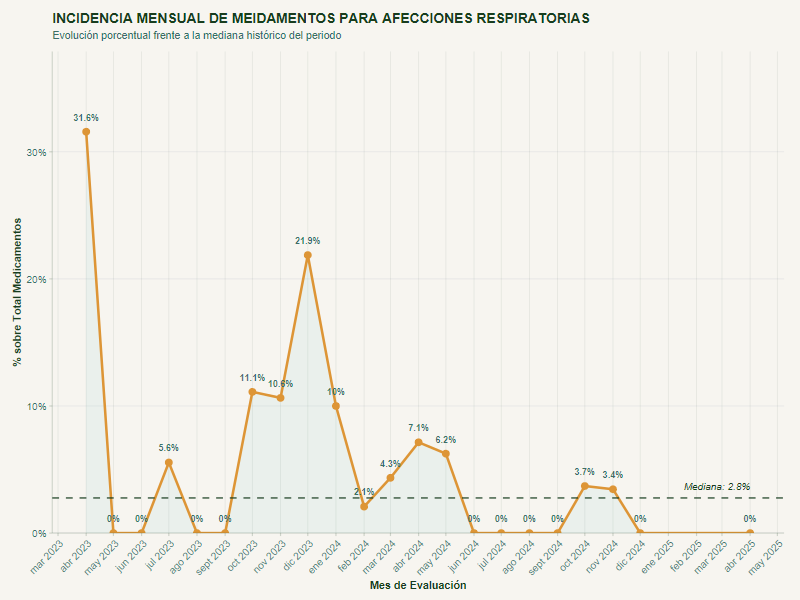

In [43]:
# 1. Procesamiento y cálculo de la media
df_respiratorio_tasa <- salud_df %>%
  mutate(Mes_Fecha = floor_date(as.Date(Fecha), "month")) %>%
  filter(!is.na(grupo_farmacologico), es_medicamento == TRUE) %>%
  group_by(Mes_Fecha) %>%
  summarise(
    Total_Mensual = sum(Total_beneficiarios, na.rm = TRUE),
    Total_Antibioticos = sum(Total_beneficiarios[grupo_farmacologico == "Respiratorio"], na.rm = TRUE),
    Tasa_Porcentaje = (Total_Antibioticos / Total_Mensual) * 100,
    .groups = 'drop'
  ) %>%
  mutate(Tasa_Porcentaje = if_else(is.nan(Tasa_Porcentaje), 0, Tasa_Porcentaje))

# Calcular el promedio global de la serie para la línea de referencia
mediana_global <- median(df_respiratorio_tasa$Tasa_Porcentaje, na.rm = TRUE)

# 2. Gráfica con línea de promedio
ggplot(df_respiratorio_tasa, aes(x = Mes_Fecha, y = Tasa_Porcentaje)) +
  
  # Área y líneas base
  geom_area(fill = PAL$cielo, alpha = 0.1) +
  geom_line(color = PAL$ave, linewidth = 1.2) +
  geom_point(color = PAL$ave, size = 3) +
  
  # LÍNEA DE PROMEDIO (Regla solicitada)
  geom_hline(yintercept = mediana_global, 
             linetype = "dashed", 
             color = PAL$hoja, 
             linewidth = 0.8, 
             alpha = 0.7) +
  
  # Etiqueta para la línea de promedio
  annotate("text", 
           x = max(df_respiratorio_tasa$Mes_Fecha), 
           y = mediana_global, 
           label = paste0("Mediana: ", round(mediana_global, 1), "%"), 
           vjust = -1, 
           hjust = 1, 
           color = PAL$hoja, 
           fontface = "italic", 
           size = 3.5) +

  # Etiquetas de porcentaje sobre los puntos
  geom_text(aes(label = paste0(round(Tasa_Porcentaje, 1), "%")), 
            vjust = -1.5, 
            size = 3.2, 
            fontface = "bold",
            color = PAL$rio) +
  
  # Escalas y Formatos
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  scale_y_continuous(labels = scales::percent_format(scale = 1), 
                     expand = expansion(mult = c(0, 0.2))) +
  
  # Etiquetas de la Fundación
  labs(
    title = "INCIDENCIA MENSUAL DE MEIDAMENTOS PARA AFECCIONES RESPIRATORIAS",
    subtitle = "Evolución porcentual frente a la mediana histórico del periodo",
    x = "Mes de Evaluación",
    y = "% sobre Total Medicamentos"
  ) +
  
  # Estilo oficial Pachamama
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.y = element_line(color = "grey90") # Retícula ligera para lectura de %
  )

### Paridad de atención por género

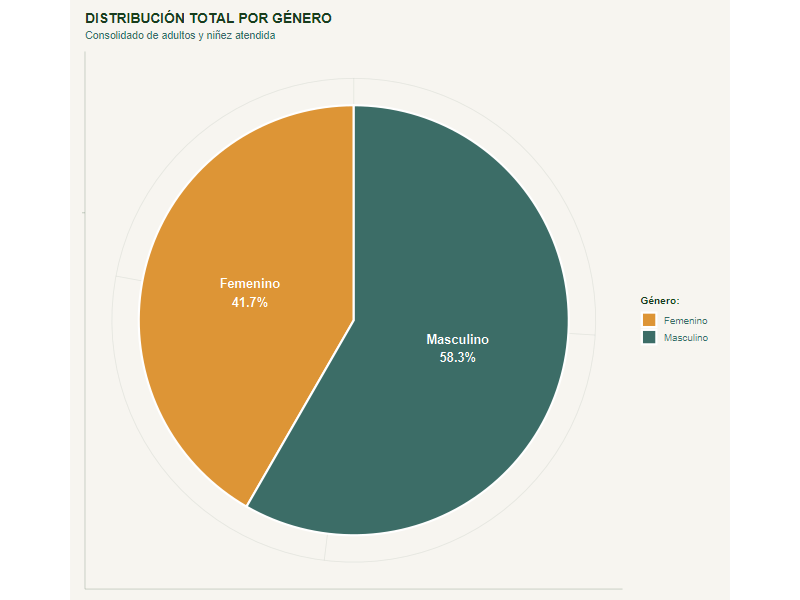

In [44]:
# 1. Consolidación de datos por Género
df_pie_genero <- salud_df %>%
  summarise(
    # Agrupamos: Mujeres + Niñas = Femenino | Hombres + Niños = Masculino
    Femenino = sum(n_mujeres, na.rm = TRUE) + sum(n_ninas, na.rm = TRUE),
    Masculino = sum(n_hombres, na.rm = TRUE) + sum(n_ninos, na.rm = TRUE)
  ) %>%
  pivot_longer(cols = everything(), names_to = "Genero", values_to = "Total") %>%
  mutate(
    # Cálculo de porcentaje
    Porcentaje = (Total / sum(Total)) * 100,
    # Etiqueta combinada para el gráfico
    Etiqueta = paste0(Genero, "\n", round(Porcentaje, 1), "%")
  ) %>%
  # Regla para evitar errores si no hay datos
  filter(Total > 0)

# 2. Creación de la Gráfica de Pastel (Pie Chart)
ggplot(df_pie_genero, aes(x = "", y = Total, fill = Genero)) +
  # Usamos geom_col con coord_polar para crear el pastel
  geom_col(width = 1, color = PAL$blanco, linewidth = 1) +
  coord_polar("y", start = 0) +
  
  # Añadir etiquetas de porcentaje dentro de las tajadas
  geom_text(aes(label = Etiqueta), 
            position = position_stack(vjust = 0.5), 
            color = PAL$blanco, 
            fontface = "bold", 
            size = 4.5) +
  
  # Aplicar colores institucionales (Río y Ave para contraste)
  scale_fill_manual(values = c("Femenino" = PAL$ave, "Masculino" = PAL$rio)) +
  
  # Etiquetas y títulos
  labs(
    title = "DISTRIBUCIÓN TOTAL POR GÉNERO",
    subtitle = "Consolidado de adultos y niñez atendida",
    fill = "Género:"
  ) +
  
  # Aplicación del tema y limpieza de ejes innecesarios para un pastel
  theme_pachamama() +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "right"
  )

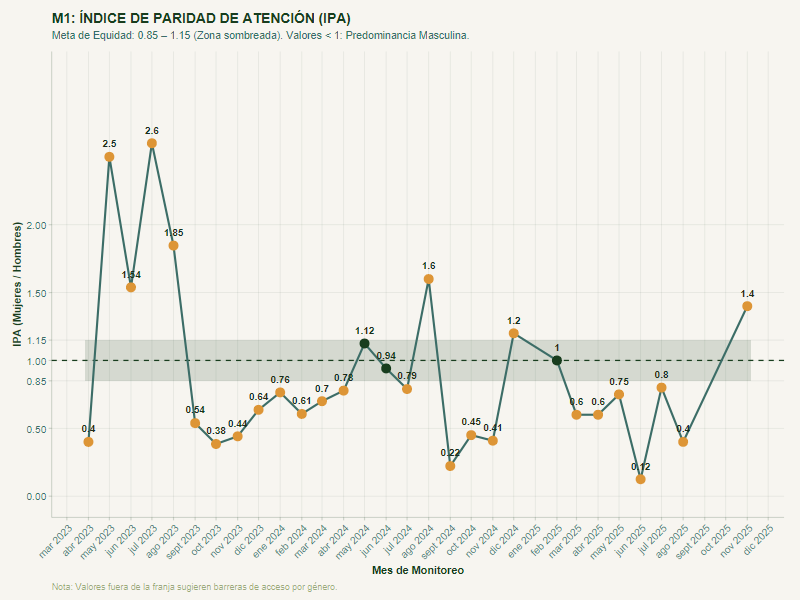

In [45]:
# 1. Cálculo del IPA Mensual con limpieza de NAs
df_ipa_mensual <- salud_df %>%
  mutate(Mes_Fecha = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes_Fecha) %>%
  summarise(
    # Consolidamos Femenino (Mujeres + Niñas) y Masculino (Hombres + Niños)
    Total_Fem = sum(n_mujeres, na.rm = TRUE) + sum(n_ninas, na.rm = TRUE),
    Total_Masc = sum(n_hombres, na.rm = TRUE) + sum(n_ninos, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  mutate(
    # REGLA: Si no hay hombres, el ratio es el total de mujeres (evita Inf)
    # Si ambos son 0, el IPA es 1 (neutralidad teórica)
    IPA = case_when(
      Total_Masc == 0 & Total_Fem == 0 ~ 1,
      Total_Masc == 0 ~ as.numeric(Total_Fem),
      TRUE ~ Total_Fem / Total_Masc
    ),
    # Etiqueta para el gráfico
    Etiqueta_IPA = round(IPA, 2)
  )

# 2. Gráfica del Índice de Paridad (M1)
ggplot(df_ipa_mensual, aes(x = Mes_Fecha, y = IPA)) +
  
  # Franja de META: 0.85 - 1.15 (Zona de Equidad)
  annotate("rect", xmin = min(df_ipa_mensual$Mes_Fecha) - 5, 
           xmax = max(df_ipa_mensual$Mes_Fecha) + 5, 
           ymin = 0.85, ymax = 1.15, 
           fill = PAL$hoja, alpha = 0.15) +
  
  # Línea de Paridad Perfecta (1.0)
  geom_hline(yintercept = 1, linetype = "dashed", color = PAL$hoja, linewidth = 0.6) +
  
  # Línea de tendencia y puntos
  geom_line(color = PAL$rio, linewidth = 1) +
  geom_point(aes(color = (IPA >= 0.85 & IPA <= 1.15)), size = 4) +
  
  # Etiquetas de valores
  geom_text(aes(label = Etiqueta_IPA), vjust = -1.2, fontface = "bold", size = 3.5, color = PAL$texto) +
  
  # Escalas de color: Verde si está en meta, Ocre (Ave) si está fuera
  scale_color_manual(values = c("TRUE" = PAL$hoja, "FALSE" = PAL$ave), guide = "none") +
  
  # Formato de ejes
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  scale_y_continuous(limits = c(0, max(df_ipa_mensual$IPA, 1.5) * 1.2), breaks = c(0, 0.5, 0.85, 1, 1.15, 1.5, 2)) +
  
  # Títulos y textos oficiales
  labs(
    title = "M1: ÍNDICE DE PARIDAD DE ATENCIÓN (IPA)",
    subtitle = "Meta de Equidad: 0.85 – 1.15 (Zona sombreada). Valores < 1: Predominancia Masculina.",
    x = "Mes de Monitoreo",
    y = "IPA (Mujeres / Hombres)",
    caption = "Nota: Valores fuera de la franja sugieren barreras de acceso por género."
  ) +
  
  # Aplicación del tema institucional
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor.y = element_blank()
  )

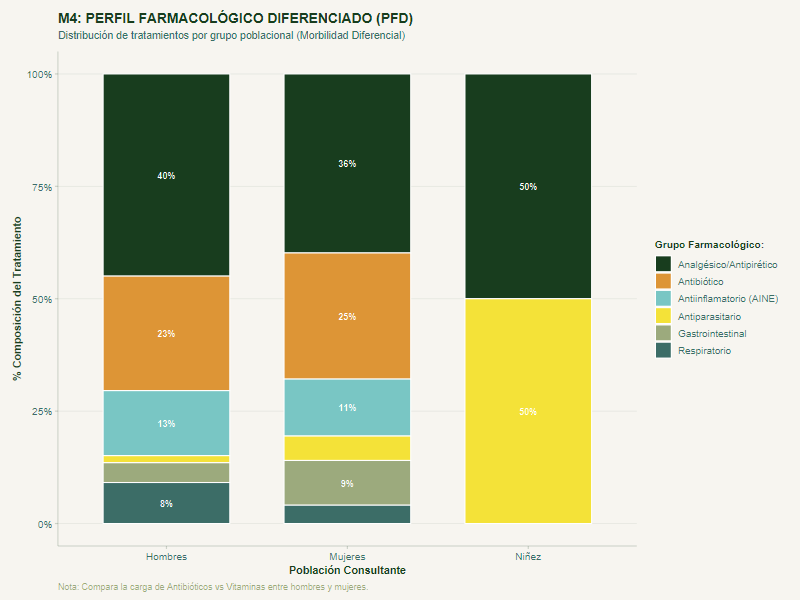

In [46]:
# 1. Preparación de los perfiles por grupo poblacional
df_pfd <- salud_df %>%
  # Creamos los 3 grandes grupos de población
  mutate(Grupo_Poblacion = case_when(
    !is.na(n_ninos) | !is.na(n_ninas) ~ "Niñez",
    !is.na(n_mujeres) ~ "Mujeres",
    !is.na(n_hombres) ~ "Hombres",
    TRUE ~ "Sin registro"
  )) %>%
  filter(Grupo_Poblacion != "Sin registro", !is.na(grupo_farmacologico)) %>%
  # Contamos registros por grupo y fármaco
  group_by(Grupo_Poblacion, grupo_farmacologico) %>%
  summarise(n = n(), .groups = 'drop') %>%
  # Calculamos el % dentro de cada grupo (PFD_grupo)
  group_by(Grupo_Poblacion) %>%
  mutate(
    Total_Grupo = sum(n),
    Porcentaje = (n / Total_Grupo) * 100,
    Etiqueta = paste0(round(Porcentaje, 0), "%")
  )%>% filter(grupo_farmacologico %in% nombres_medicamentos_filtrados)


# 2. Gráfica de Perfil Farmacológico Diferenciado (M4)
ggplot(df_pfd, aes(x = Grupo_Poblacion, y = Porcentaje, fill = grupo_farmacologico)) +
  # Barras apiladas al 100%
  geom_col(position = "fill", width = 0.7, color = PAL$blanco) +
  
  # Añadimos las etiquetas de porcentaje dentro de las barras
  geom_text(aes(label = if_else(Porcentaje > 5, Etiqueta, "")), 
            position = position_fill(vjust = 0.5), 
            color = PAL$blanco, 
            fontface = "bold", 
            size = 3.2) +
  
  # Aplicamos la paleta cualitativa oficial
  scale_fill_manual(values = PAL_CUAL) +
  
  # Formato de porcentaje en el eje Y
  scale_y_continuous(labels = scales::percent_format()) +
  
  # Etiquetas y títulos
  labs(
    title = "M4: PERFIL FARMACOLÓGICO DIFERENCIADO (PFD)",
    subtitle = "Distribución de tratamientos por grupo poblacional (Morbilidad Diferencial)",
    x = "Población Consultante",
    y = "% Composición del Tratamiento",
    fill = "Grupo Farmacológico:",
    caption = "Nota: Compara la carga de Antibióticos vs Vitaminas entre hombres y mujeres."
  ) +
  
  # Aplicación del tema institucional
  theme_pachamama() +
  theme(
    legend.position = "right",
    panel.grid.major.x = element_blank()
  )

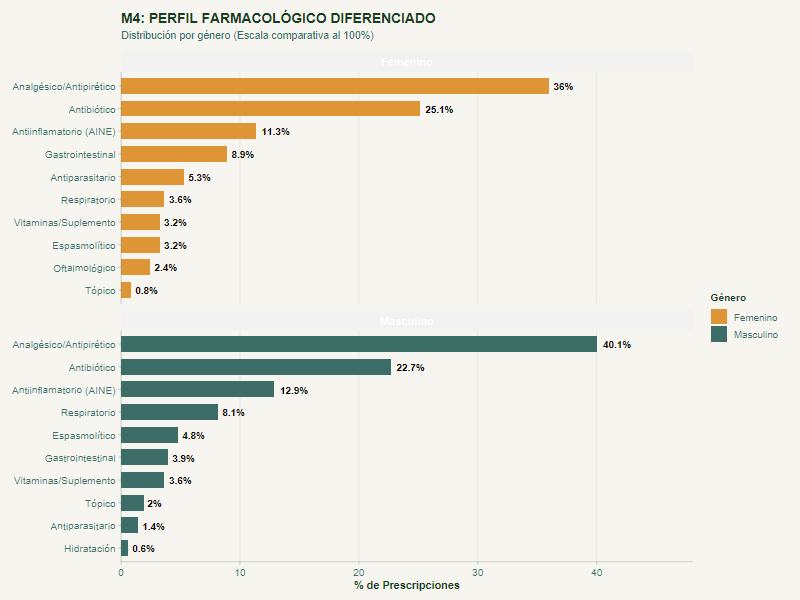

In [47]:
# Asegúrate de cargar esta librería para el ordenamiento interno


# 1. Preparación de datos (Igual al anterior)
df_pfd_separado <- salud_df %>%
  mutate(Genero_Grupo = case_when(
    !is.na(n_mujeres) | !is.na(n_ninas) ~ "Femenino",
    !is.na(n_hombres) | !is.na(n_ninos) ~ "Masculino",
    TRUE ~ NA_character_
  )) %>%
  filter(!is.na(Genero_Grupo), !is.na(grupo_farmacologico)) %>%
  group_by(Genero_Grupo, grupo_farmacologico) %>%
  summarise(n = n(), .groups = 'drop') %>%
  group_by(Genero_Grupo) %>%
  mutate(
    Total_Genero = sum(n),
    Porcentaje = (n / Total_Genero) * 100,
    # Crucial para que cada panel ordene sus barras
    grupo_farmacologico = reorder_within(grupo_farmacologico, Porcentaje, Genero_Grupo)
  )

# 2. Gráfica con Leyenda Habilitada
ggplot(df_pfd_separado, aes(x = Porcentaje, y = grupo_farmacologico, fill = Genero_Grupo)) +
  # Cambiamos show.legend a TRUE (o lo omitimos ya que es el default)
  geom_col(width = 0.7, show.legend = TRUE) +
  
  # Etiquetas de porcentaje
  geom_text(aes(label = paste0(round(Porcentaje, 1), "%")), 
            hjust = -0.2, 
            size = 3.5, 
            fontface = "bold") +
  
  # Facetado en dos filas (uno sobre otro)
  facet_wrap(~Genero_Grupo, scales = "free_y", ncol = 1) +
  
  # Ajustes de escalas
  scale_y_reordered() + 
  scale_x_continuous(expand = expansion(mult = c(0, 0.2))) +
  scale_fill_manual(values = c("Femenino" = PAL$ave, "Masculino" = PAL$rio)) +
  
  # Etiquetas
  labs(
    title = "M4: PERFIL FARMACOLÓGICO DIFERENCIADO",
    subtitle = "Distribución por género (Escala comparativa al 100%)",
    x = "% de Prescripciones",
    y = NULL,
    fill = "Género"
  ) +
  
  # Tema Pachamama con leyenda activa
  theme_pachamama() +
  theme(
    legend.position = "right", # Forzamos la posición a la derecha
    panel.grid.major.y = element_blank(),
    strip.background = element_rect(fill = "grey95"), # Un fondo ligero para los títulos de género
    strip.text = element_text(face = "bold", size = 11)
  )

### Resumen de actividades

In [48]:
conteo_palabras <- data.frame(texto = salud_df$Descripcion_accion) %>%
  mutate(texto = str_to_lower(texto) %>% str_replace_all("[^[:alpha:][:space:]]", ""))



Basado en el registro de actividades de salud proporcionado, el trabajo se centró principalmente en la gestión farmacéutica y el acompañamiento familiar. A continuación se detallan las categorías principales de intervención:

**1. Entrega de Medicamentos y Suministros**
Esta fue la actividad más recurrente del proyecto. Se registró la entrega constante de fármacos para tratar diversas dolencias:

Analgésicos y Antipiréticos: Uso frecuente de Finalin, Paracetamol (o Paracetanol), Ibuprofeno y Paralgen.

Antibióticos: Distribución de Amoxicilina, Ampicilina y Dicloxacilina.

Salud Gastrointestinal: Entrega de Diaren, Albendazol (antiparasitario) y probióticos como Enterogermina.

Vitaminas y Suplementos: Provisión de Neurobión, Bedoyecta y soluciones orales.

Otros: Se entregaron jarabes, antiinflamatorios (Diclofenaco), antiespasmódicos (Buscapina) y productos tópicos como Mentol Chino o Mentol Panalgesic.

**2. Visitas y Acompañamiento Familiar**
El equipo realizó un monitoreo directo en los hogares para verificar el estado de salud de los beneficiarios:

Grupos Prioritarios: Se realizaron visitas específicas para el control de niños y mujeres embarazadas.


Familias Recurrentes: Se registran múltiples visitas a las familias Pitiur, Roberto Peas, René Canelos y Soledad Vargas.

Gestión de Casos: Visitas individuales a pacientes como el Sr. Tii Yunkar, Juan Jimpikit y Ana Tentets.

**3. Gestión y Salud Comunitaria**
Además de la entrega directa, se realizaron acciones de prevención y coordinación institucional:

Brigadas Médicas: Acompañamiento a la brigada médica del Patronato y visitas al puesto de salud Kapawi.

Saneamiento: Realización de hoyos sanitarios como medida de prevención ambiental.

Pruebas de Salud: Ejecución de pruebas específicas (mencionada "prueba rabita") a miembros de la comunidad.

Educación: Entrega de útiles escolares en el CECIB Uwiti a través del proyecto relacionado "Violín Rojo".

**Resumen de Intervención**
El proyecto operó como un puente de asistencia básica en salud, asegurando que las familias tuvieran acceso a medicamentos esenciales y recibieran atención personalizada en sus domicilios, complementando la labor de los centros de salud locales.



# Otras actividades

In [49]:
Otras_actividades = planesv_df_0%>%filter(Actividad_monitorear == "Otro")%>%pull( Descripcion_accion)
Otras_actividades

 [1] "El nuevo sendero de Sharam."                                                                                                 
 [2] "El nuevo sendero de Sharam."                                                                                                 
 [3] "El equipo de amazank realizo la limpieza de panel solar de Karasolar."                                                       
 [4] "El equipo de amazank realizo la limpieza de panel solar de Karasolar."                                                       
 [5] "El equipo de amazank realizo la limpieza de panel solar de Karasolar."                                                       
 [6] "Se realizo la limpieza del limite territorial de Sharamentsa-Charapacocha."                                                  
 [7] "Se realizo la limpieza del limite territorial de Sharamentsa-Charapacocha."                                                  
 [8] "Se realizo la limpieza del invernadero alrededor e interno."          